# Feature Engineering Pipeline
> **Notebook 1/3** — Download → Engineer Features → Build Sequences → Split → Save
>
> Output is saved to `data/feature_store/` as `.npz` + metadata JSON  
> so Notebook 2 (Training) can just call `load_feature_store()` and start right away.

## 1. 📦 Import & Config

In [92]:
import sys, re, math, json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pathlib import Path
from datetime import datetime
from typing import List, Annotated

# Finance Libs
import yfinance as yf
import talib as ta

from talib import abstract

# Torch & Sklearn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Subset

In [93]:
from config import Config, Indicator
from datasets import MarketDataset
from utils import plot_return_dist, plot_compare_dist, plot_correlation, plot_rolling_vol, plot_compare_correlation, plot_compare_rolling_vol

In [94]:
# Instantiate Config
cfg = Config(
    # processed_name="trial01_w5h30a14rand78"
)

cfg.inference.window_size = 150

# Helper to compute horizon from the expected test-period length
# If 322 is the planned test set length, horizon should be the remaining days
# after the input window is used.
def calc_horizon(test_days: int, window_size: int) -> int:
    if test_days <= window_size:
        raise ValueError("test_days must be greater than window_size")
    return test_days - window_size

# Example: if we reserve 322 days for test, horizon is the remaining days after the window.
cfg.inference.horizon = calc_horizon(test_days=322, window_size=cfg.inference.window_size)

data_shifted = cfg.inference.horizon
cfg.inference.normalize_shift = data_shifted  # Not necessary to be the same as window_size, but it makes sense to use the same value
# ---------------------------------------
cfg.feature.indicator_shift = data_shifted  # Shift the indicators by the window size to avoid look-ahead bias
cfg.inference.normalize_window = True
cfg.feature.sequence_depth = 180
cfg.inference.test_batch_stride = cfg.inference.window_size

cfg.processed_name = f"trial03_w{cfg.inference.window_size}seqd{cfg.feature.sequence_depth}tbs{cfg.inference.test_batch_stride}h{cfg.inference.horizon}inds{cfg.feature.indicator_shift}a{len(cfg.feature.symbols)}rand{cfg.random_seed}"
cfg.dataset_ratios = [0.8, 0.1, 0.1]  # train, val, test
cfg.feature.start_date = "2013-01-01"
cfg.feature.end_date = "2025-12-31"

# Unpack the fields which use throughout this notebook
dataset_ratios      = cfg.dataset_ratios
processed_name      = cfg.processed_name
save_processed_dir  = cfg.save_processed_dir

# Save Dir
plots_dir = save_processed_dir / processed_name / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

tables_dir = save_processed_dir / processed_name / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

# Feature Config
symbols             = cfg.feature.symbols
interval            = cfg.feature.interval
start_date          = cfg.feature.start_date
end_date            = cfg.feature.end_date
indicators          = cfg.feature.indicators
indicator_period    = cfg.feature.indicator_period
indicator_shift     = cfg.feature.indicator_shift
sequence_depth      = cfg.feature.sequence_depth
sequence_mode       = cfg.feature.sequence_mode
feature_target      = cfg.feature.target
# Train Config
batch_size          = cfg.train.batch_size
batch_size_test     = cfg.train.batch_size_test
# Inference Config
horizon             = cfg.inference.horizon
window_size         = cfg.inference.window_size
normalize_shift     = cfg.inference.normalize_shift
normalize_window    = cfg.inference.normalize_window
stride              = cfg.inference.stride
test_batch_stride   = cfg.inference.test_batch_stride

print(f"Symbols  : {symbols}")
print(f"Period   : {start_date} → {end_date}")
print(f"Seq mode : {sequence_mode}  depth={sequence_depth}  steps_sim={horizon}")
print(f"Window   : {window_size}  normalize_shift={normalize_shift}")

Symbols  : ['AAPL', 'TSLA', 'MSFT', 'NVDA', 'GOOGL', 'AMZN', 'GOOG', 'META', 'AVGO', 'ORCL', 'CRM', 'ADBE', 'AMD', 'CSCO']
Period   : 2013-01-01 → 2025-12-31
Seq mode : Backward  depth=180  steps_sim=172
Window   : 150  normalize_shift=172


## 2. ✨ Download & Clean Raw Data

In [95]:
df      = yf.download(symbols, start=start_date, end=end_date, interval=interval)
assets  = df.columns.get_level_values(1).unique().tolist()

print(f"Downloaded {len(assets)} assets  |  {len(df)} trading days")
print(f"Date range : {df.index[0].date()} → {df.index[-1].date()}")

[*********************100%***********************]  14 of 14 completed


Downloaded 14 assets  |  3269 trading days
Date range : 2013-01-02 → 2025-12-30


In [96]:
def plot_missing_data(df: pd.DataFrame, assets: list[str], column: str):
    # Quick visual check for gaps in a price series.
    prices = df[column]
    fig, axes = plt.subplots(len(assets), 1, figsize=(14, max(8, len(assets) * 1.2)))

    for ax, sym in zip(axes, assets):
        series = prices[sym]
        ax.plot(series.index, series.values, lw=0.8, label=sym)
        nan_idx = series.index[series.isna()]
        if len(nan_idx):
            ax.scatter(nan_idx, [series.mean()] * len(nan_idx),
                       color="red", marker="x", s=40, zorder=5, label="NaN")
        ax.set_title(sym, fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    nan_counts = df[column].isna().sum()
    if nan_counts.any():
        print("NaN counts per asset:")
        print(nan_counts[nan_counts > 0].to_string())
    else:
        print("No NaN values found in Close prices.")

def process_missing_data(df: pd.DataFrame) -> pd.DataFrame:
    # Drop incomplete leading rows
    first_valid = df.notna().all(axis=1).idxmax()
    df = df.loc[first_valid:]

    # Forward-fill any remaining gaps
    df.ffill(inplace=True)

    return df

### 2.1 Quick visual check for gaps in a price series.

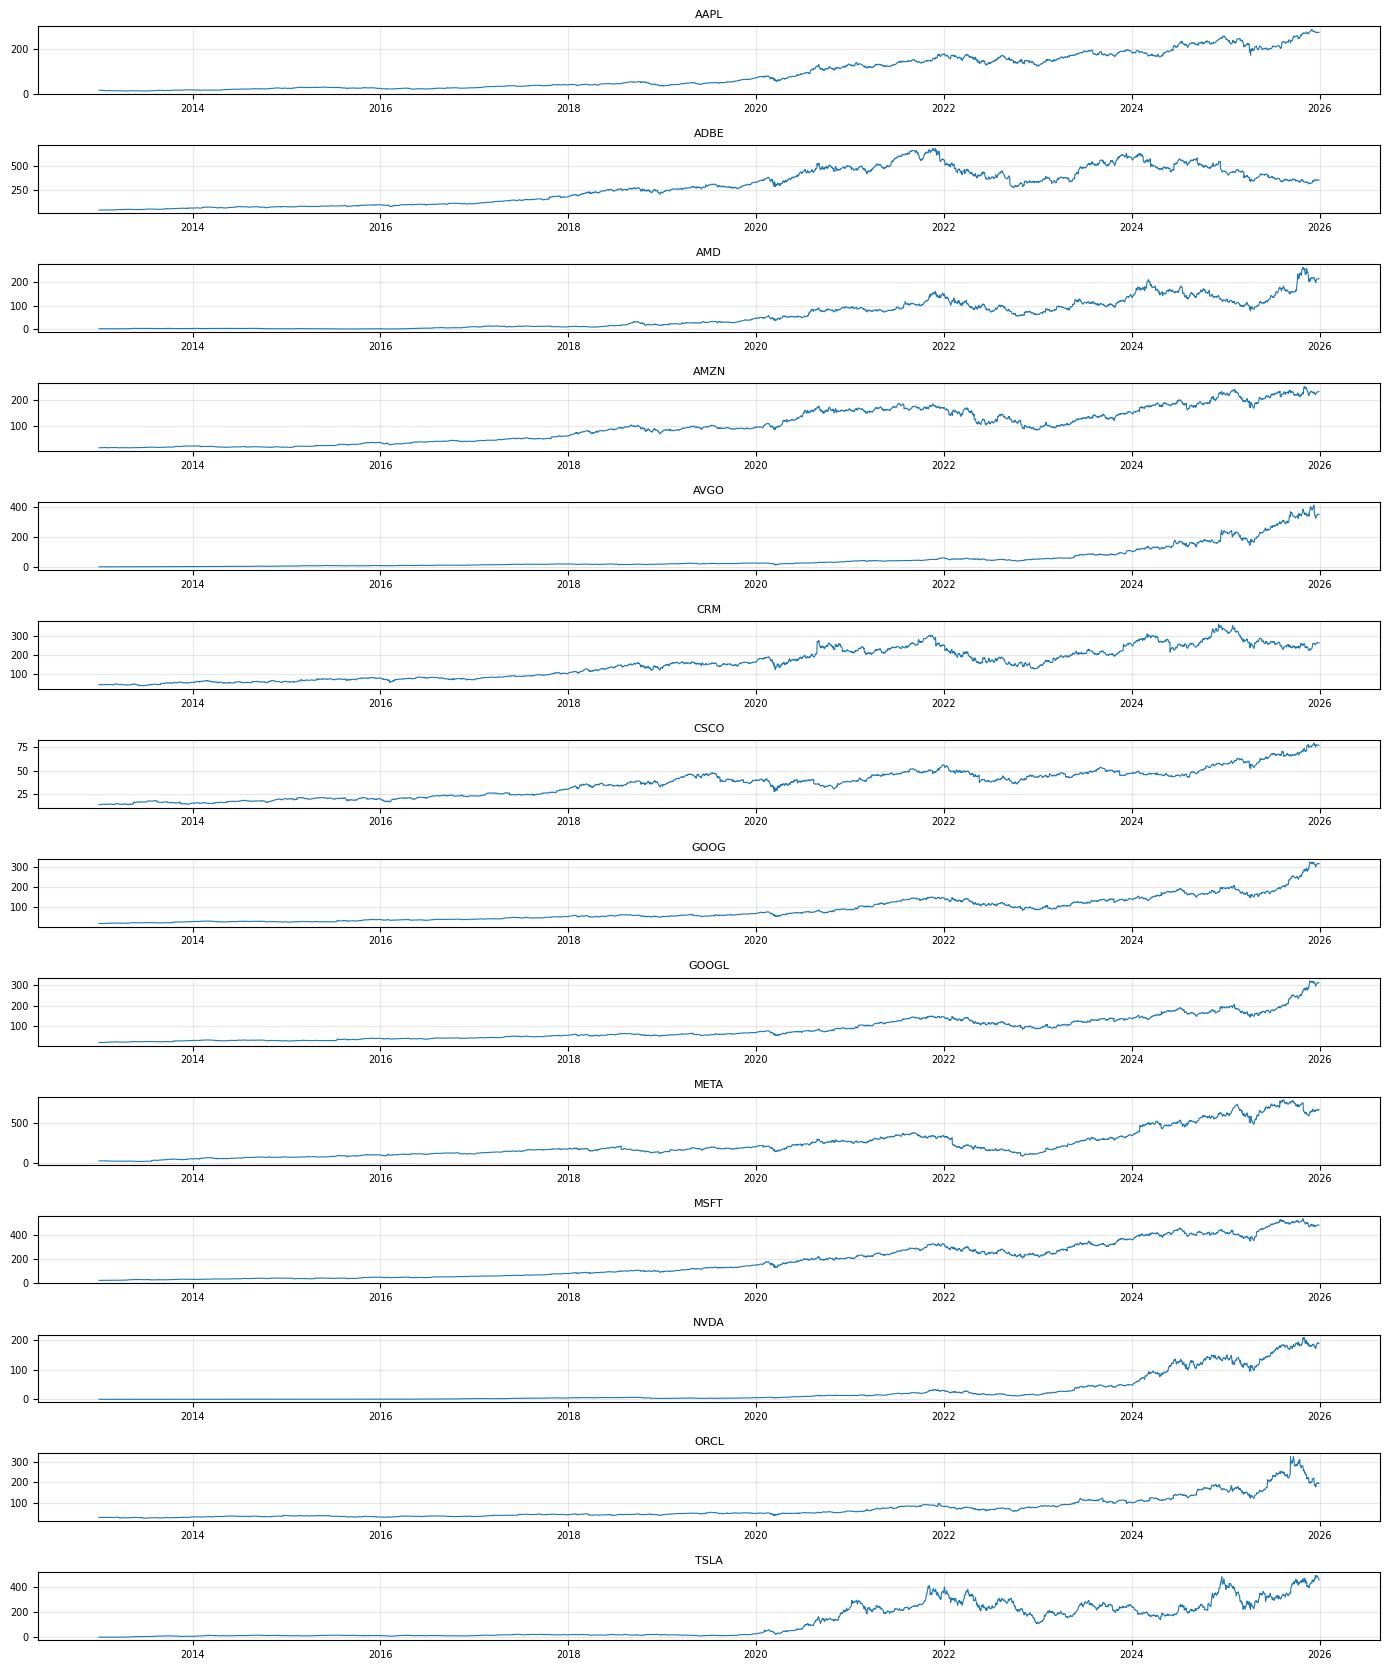

No NaN values found in Close prices.


In [97]:
plot_missing_data(df, assets, "Close")

### 2.2 Process missing data

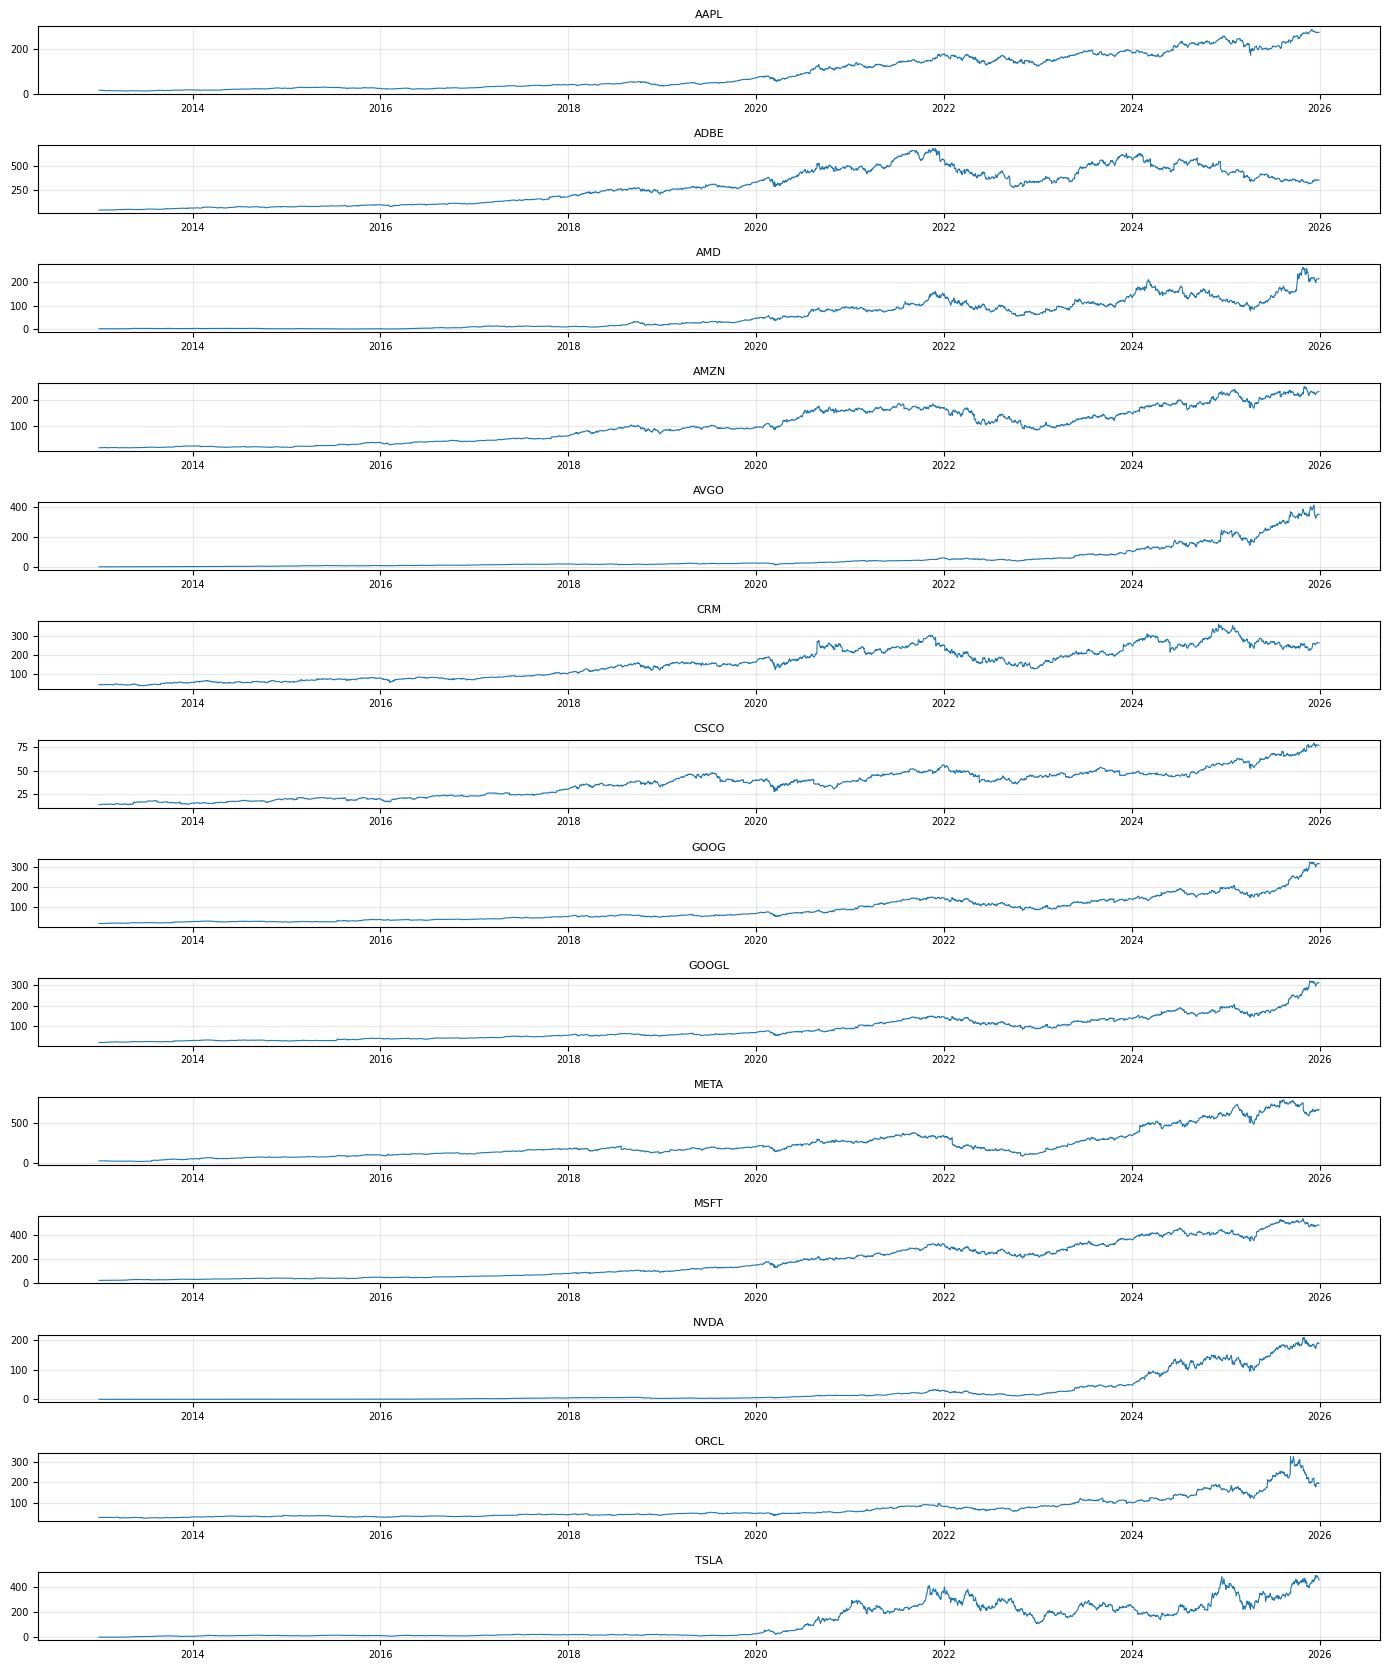

No NaN values found in Close prices.


In [98]:
df = process_missing_data(df)
plot_missing_data(df, assets, column="Close")

## 3. ⚙️ Feature Engineering

In [99]:
def apply_normalization(series: pd.Series, norm_type: str, period: int, close_prices: pd.Series = None) -> pd.Series:
    if norm_type is None:
        return series

    if norm_type == "zscore":
        # (X - Mean) / Std
        return (series - series.rolling(period).mean()) / series.rolling(period).std()
    elif norm_type == "minmax":
        # (X - Min) / (Max - Min)
        roll_min = series.rolling(period).min()
        roll_max = series.rolling(period).max()
        return (series - roll_min) / (roll_max - roll_min)
    elif norm_type == "pct_change":
        # Percentage Change
        return series.pct_change()
    elif norm_type == "distance_close":
        # Distance between Close price (SMA, EMA)
        if close_prices is not None:
            return (close_prices - series) / close_prices
        else:
            raise ValueError("distance_close requires 'close_prices' to be provided.")
    else:
        print(f"Warning: Unknown norm_type '{norm_type}'. Returning original series.")
        return series

def extract_indicators_per_asset(
    ohlcv: pd.DataFrame,
    symbol: str,
    indicators: List[Indicator],
    indicator_shift: int,
    indicator_period: int,
) -> pd.DataFrame:
    df = ohlcv.copy()

    close = df["Close"]
    ohlcv_dict = {
        'open': df['Open'].values,
        'high': df['High'].values,
        'low': df['Low'].values,
        'close': df['Close'].values,
        'volume': df['Volume'].values
    }

    for indicator in indicators:
        try:
            func = abstract.Function(indicator.name) # Dynamic ta function
            result = func(ohlcv_dict, **indicator.params)
            out_names = func.info['output_names']

            if isinstance(result, (tuple, list)):
                for i, out_arr in enumerate(result):
                    val = pd.Series(out_arr, index=df.index)
                    val = apply_normalization(val, indicator.norm_type, indicator.params.get('timeperiod', indicator_period), close)

                    col_name = f"{indicator.name.upper()}_{out_names[i]}"
                    if indicator.norm_type: col_name += f"_{indicator.norm_type}"

                    df[col_name] = val.shift(indicator_shift)
            else:
                val = pd.Series(result, index=df.index)
                val = apply_normalization(val, indicator.norm_type, indicator.params.get('timeperiod', indicator_period), close)

                param_str = "_".join([str(v) for v in indicator.params.values()])
                col_name = f"{indicator.name.upper()}_{param_str}" if param_str else indicator.name.upper()
                if indicator.norm_type: col_name += f"_{indicator.norm_type}"

                df[col_name] = val.shift(indicator_shift)
        except Exception as e:
            print(f"Error calculating {indicator.name} for {symbol}: {e}")
            continue

    df.columns = pd.MultiIndex.from_product([[symbol], df.columns])
    return df

def extract_features_per_asset(
    ohlcv: pd.DataFrame,
    symbol: str,
    feature_shift: int,
    features: dict,
) -> pd.DataFrame:
    df = ohlcv.copy()

    close = df["Close"]
    volume = df["Volume"]
    high   = df["High"]
    low    = df["Low"]



    return df

def create_features(
        df: pd.DataFrame,
        assets: list[str],
        indicators: dict,
        indicator_period: int,
        indicator_shift: int,
        drop_ohlcv: bool = True,
):
    # Indicators
    if indicators is None:
        raise "No Indicator as a feature"

    dfs = [
        extract_indicators_per_asset(
            ohlcv=df.xs(sym, level=1, axis=1),
            symbol=sym,
            indicators=indicators,
            indicator_shift=indicator_shift,
            indicator_period=indicator_period,
        ) for sym in assets
    ]

    df = pd.concat(dfs, axis=1)

    if drop_ohlcv:
        drop_cols = [c for c in ["Open", "High", "Low", "Volume", "Close"]
                     if c in df.columns.get_level_values(1)]
        if drop_cols:
            df = df.drop(columns=drop_cols, level=1)

    print(f"Feature DataFrame : {df.shape}  (before dropna)")
    print(f"Features per asset: {sorted(df.columns.get_level_values(1).unique().tolist())}")
    return df

In [100]:
df_featured = create_features(
    df,
    assets,
    indicators=indicators,
    indicator_period=indicator_period,
    indicator_shift=indicator_shift,
    drop_ohlcv=True,
)

# Quick sanity check — show one asset
df_featured.xs("AAPL", axis=1, level=0).tail(5)

Feature DataFrame : (3269, 112)  (before dropna)
Features per asset: ['BBANDS_lowerband_distance_close', 'BBANDS_middleband_distance_close', 'BBANDS_upperband_distance_close', 'MACD_macd', 'MACD_macdhist', 'MACD_macdsignal', 'RSI_14_minmax', 'SMA_20_distance_close']


Price,RSI_14_minmax,SMA_20_distance_close,MACD_macd,MACD_macdsignal,MACD_macdhist,BBANDS_upperband_distance_close,BBANDS_middleband_distance_close,BBANDS_lowerband_distance_close
Date,,,,,,,,
2025-12-23,0.805737,-0.046812,-7.738917,-8.140368,0.401451,-0.205875,-0.046812,0.112251
2025-12-24,0.738440,-0.061014,-7.668505,-8.045996,0.377490,-0.223105,-0.061014,0.101077
2025-12-26,0.894077,-0.020807,-7.003325,-7.837461,0.834137,-0.173606,-0.020807,0.131992
2025-12-29,1.000000,0.008121,-6.016353,-7.473240,1.456886,-0.134297,0.008121,0.150539
2025-12-30,1.000000,0.029224,-4.875089,-6.953610,2.078521,-0.105161,0.029224,0.163610


Total NaN: 22092


Price,RSI_14_minmax,SMA_20_distance_close,MACD_macd,MACD_macdsignal,MACD_macdhist,BBANDS_upperband_distance_close,BBANDS_middleband_distance_close,BBANDS_lowerband_distance_close
AAPL,199,191,205,205,205,191,191,191
ADBE,199,191,205,205,205,191,191,191
AMD,199,191,205,205,205,191,191,191
AMZN,199,191,205,205,205,191,191,191
AVGO,199,191,205,205,205,191,191,191
CRM,199,191,205,205,205,191,191,191
CSCO,199,191,205,205,205,191,191,191
GOOG,199,191,205,205,205,191,191,191
GOOGL,199,191,205,205,205,191,191,191
META,199,191,205,205,205,191,191,191


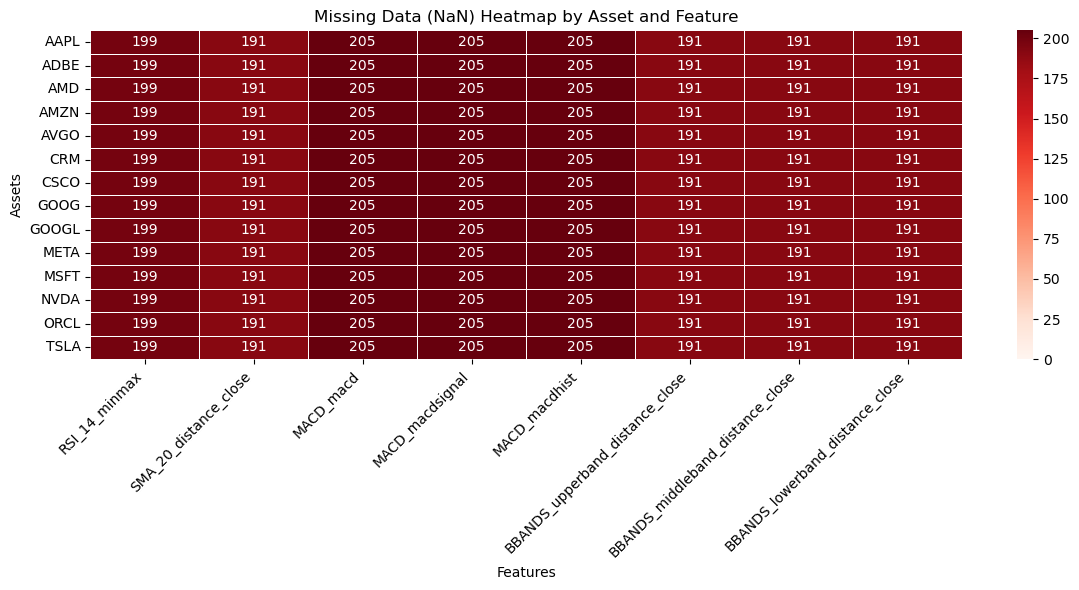

In [101]:
def summarize_missing_features(df: pd.DataFrame):
    missing_counts = df.isna().sum().unstack(level=1)
    print(f"Total NaN: {missing_counts.sum().sum()}")
    display(missing_counts)

    plt.figure(figsize=(12, max(6, len(missing_counts) * 0.4)))
    sns.heatmap(missing_counts, annot=True, fmt="d", cmap="Reds", cbar=True, linewidths=0.5, vmin=0)
    plt.title("Missing Data (NaN) Heatmap by Asset and Feature")
    plt.xlabel("Features")
    plt.ylabel("Assets")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return missing_counts

missing_summary = summarize_missing_features(df_featured)

## 4. 📊 Feature Analysis
> 1. Return distribution & statistics per asset
> 2. Correlation heatmap (assets + features)
> 3. Rolling volatility regime
> 4. PCA — feature importance & market mode
> 5. t-SNE / UMAP — market regime clustering

### 4.1 Log-Return Distribution per Asset

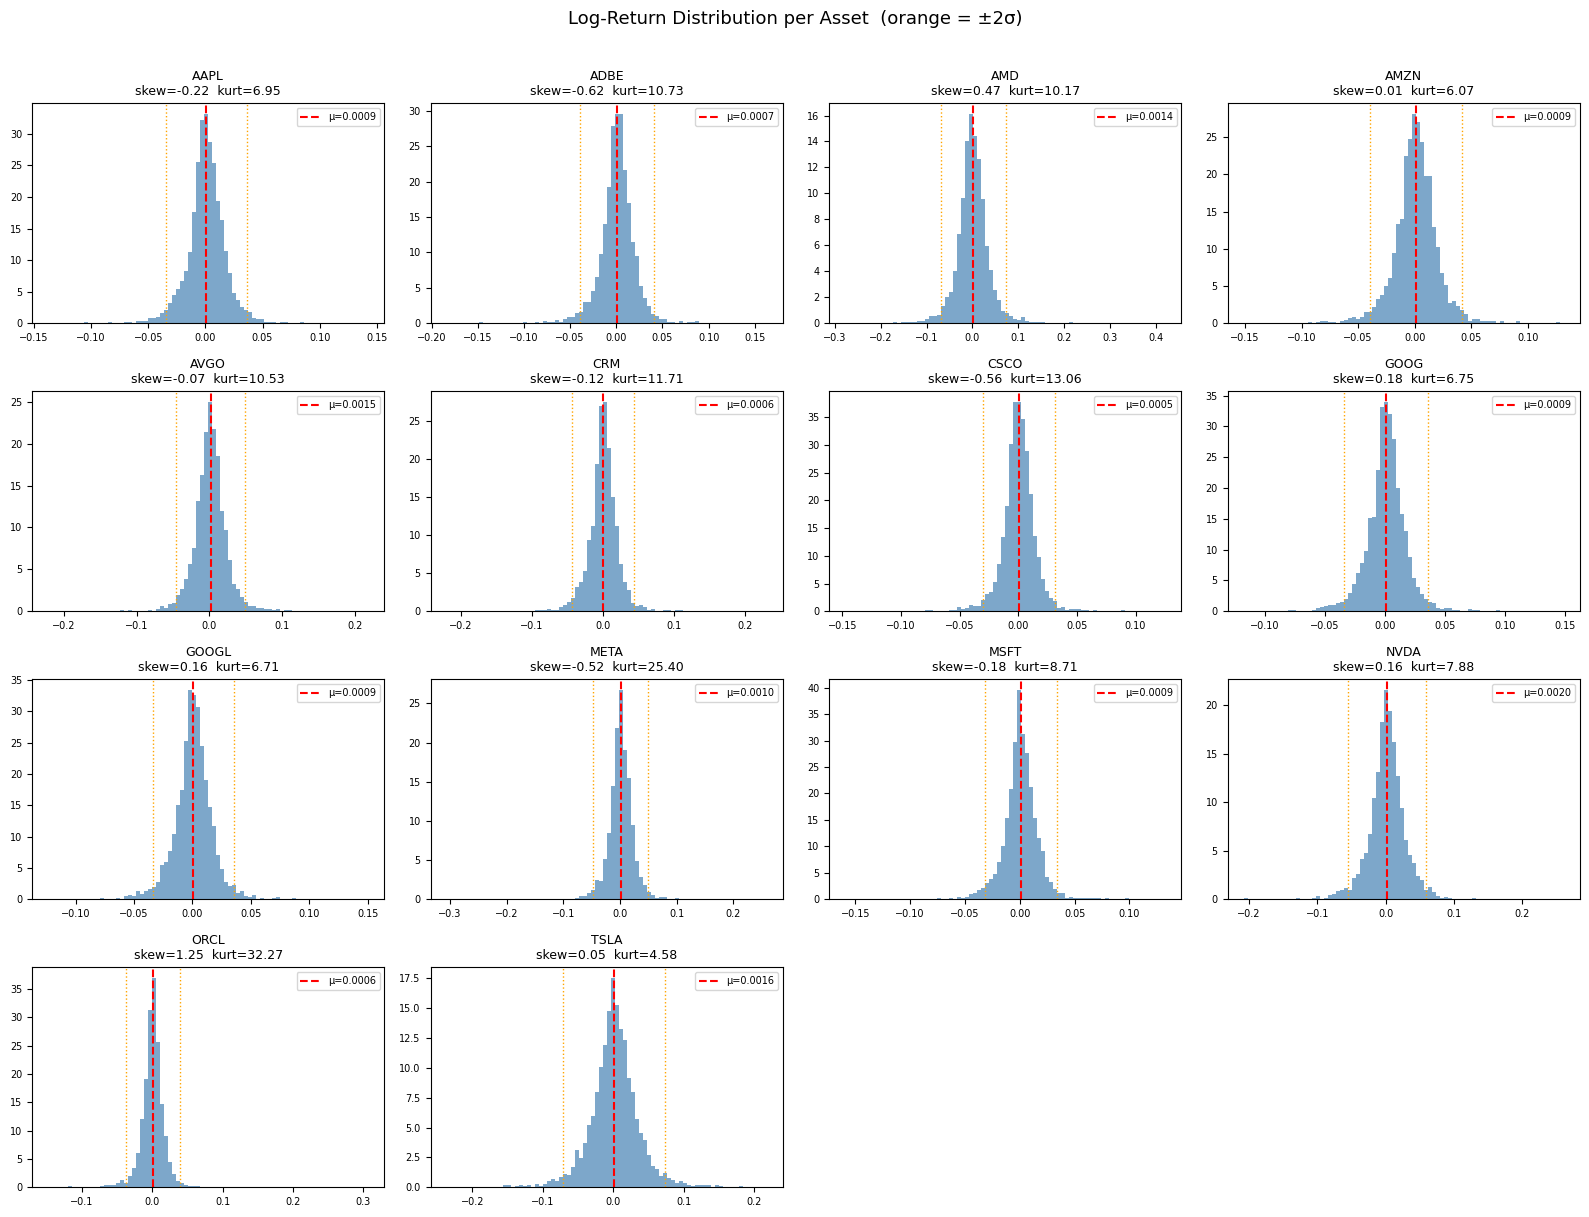


Return Statistics (sorted by volatility):


,Mean,Std,Skewness,Excess Kurt
Ticker,,,,
TSLA,0.0016,0.0363,0.0519,4.5816
AMD,0.0014,0.0354,0.4682,10.1705
NVDA,0.0020,0.0286,0.1626,7.8814
META,0.0010,0.0240,-0.5225,25.4004
AVGO,0.0015,0.0238,-0.0683,10.5258
CRM,0.0006,0.0216,-0.1162,11.7100
AMZN,0.0009,0.0204,0.0140,6.0657
ADBE,0.0007,0.0202,-0.6158,10.7327
ORCL,0.0006,0.0190,1.2507,32.2749


In [102]:
close_prices = df.xs("Close", axis=1, level=0)   # [T, A]
log_returns = np.log(close_prices / close_prices.shift(1)).dropna()

n_assets = len(assets)
n_cols = 4
n_rows = (n_assets + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, sym in enumerate(assets):
    r    = log_returns[sym].dropna()
    mu   = r.mean()
    std  = r.std()
    skew = r.skew()
    kurt = r.kurtosis()

    axes[i].hist(r, bins=80, density=True, alpha=0.7, color="steelblue", edgecolor="none")
    axes[i].axvline(mu, color="red",    lw=1.5, linestyle="--", label=f"μ={mu:.4f}")
    axes[i].axvline(mu + 2*std, color="orange", lw=1, linestyle=":")
    axes[i].axvline(mu - 2*std, color="orange", lw=1, linestyle=":")
    axes[i].set_title(f"{sym}\nskew={skew:.2f}  kurt={kurt:.2f}", fontsize=9)
    axes[i].tick_params(labelsize=7)
    axes[i].legend(fontsize=7)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Log-Return Distribution per Asset  (orange = ±2σ)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(plots_dir / "return_dist.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary stats table
stats_df = log_returns.agg(["mean","std","skew","kurtosis"]).T
stats_df.columns = ["Mean","Std","Skewness","Excess Kurt"]
stats_df = stats_df.sort_values("Std", ascending=False)
stats_df.to_csv(tables_dir / "return_stats.csv")
print("\nReturn Statistics (sorted by volatility):")
display(stats_df.style.background_gradient(cmap="RdYlGn_r", subset=["Std"])
                      .format("{:.4f}"))


### 4.2 Asset Correlation Heatmap

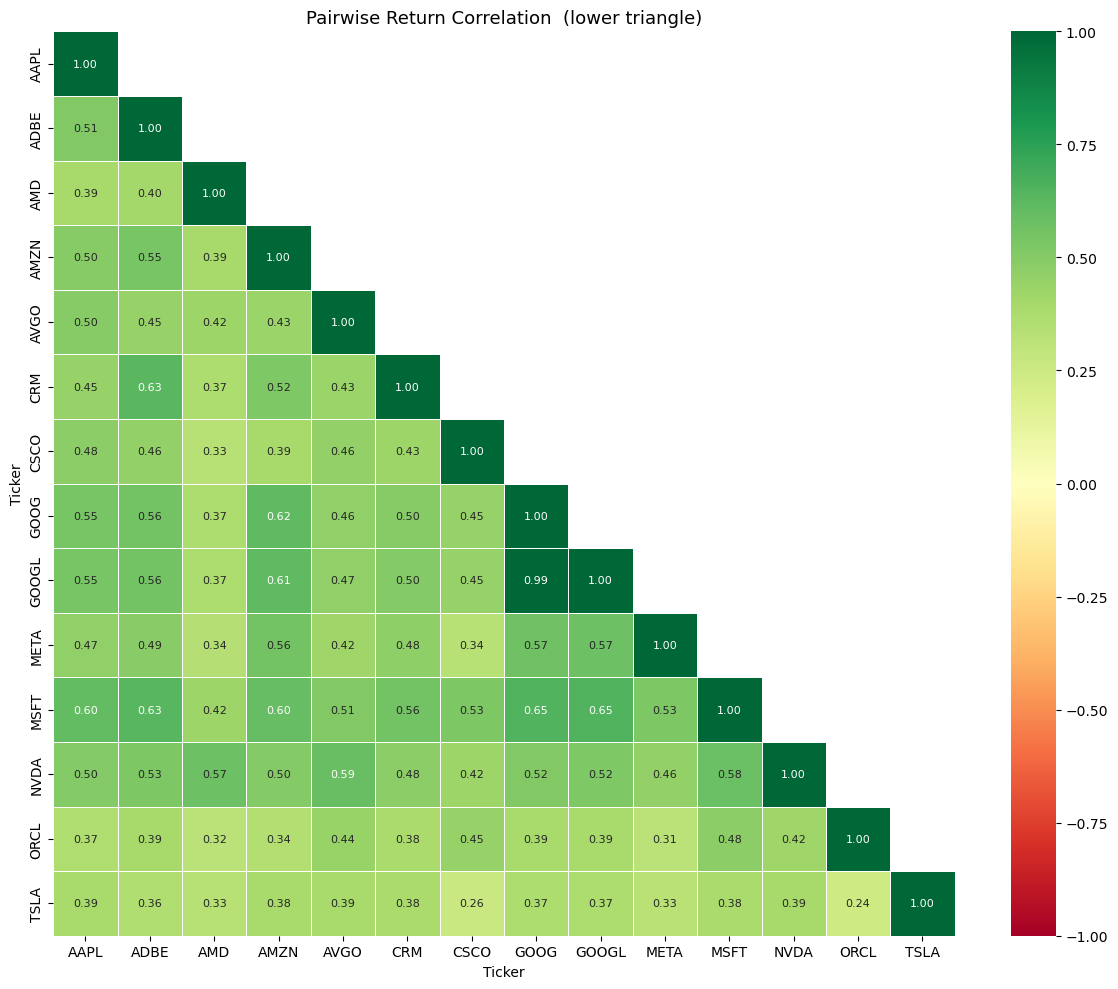


Highly correlated pairs (|r| > 0.85):


,Asset A,Asset B,r
0,GOOG,GOOGL,0.995


In [103]:
corr = log_returns.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle mask

sns.heatmap(
    corr,
    mask=mask,
    annot=True, fmt=".2f", annot_kws={"size": 8},
    cmap="RdYlGn", vmin=-1, vmax=1,
    linewidths=0.4, linecolor="white",
    ax=ax
)
ax.set_title("Pairwise Return Correlation  (lower triangle)", fontsize=13)
plt.tight_layout()
plt.savefig(plots_dir / "return_correlation.png", dpi=150, bbox_inches="tight")  # ← เพิ่ม
plt.show()

# Highlight highly correlated pairs
print("\nHighly correlated pairs (|r| > 0.85):")
pairs = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        r = corr.iloc[i, j]
        if abs(r) > 0.85:
            pairs.append({"Asset A": corr.index[i], "Asset B": corr.columns[j], "r": round(r, 3)})
if pairs:
    pd.DataFrame(pairs).sort_values("r", ascending=False).to_csv(tables_dir / "high_corr_pairs.csv", index=False)
    display(pd.DataFrame(pairs).sort_values("r", ascending=False))
else:
    print("  None found.")

### 4.3 Rolling Volatility — Market Regime

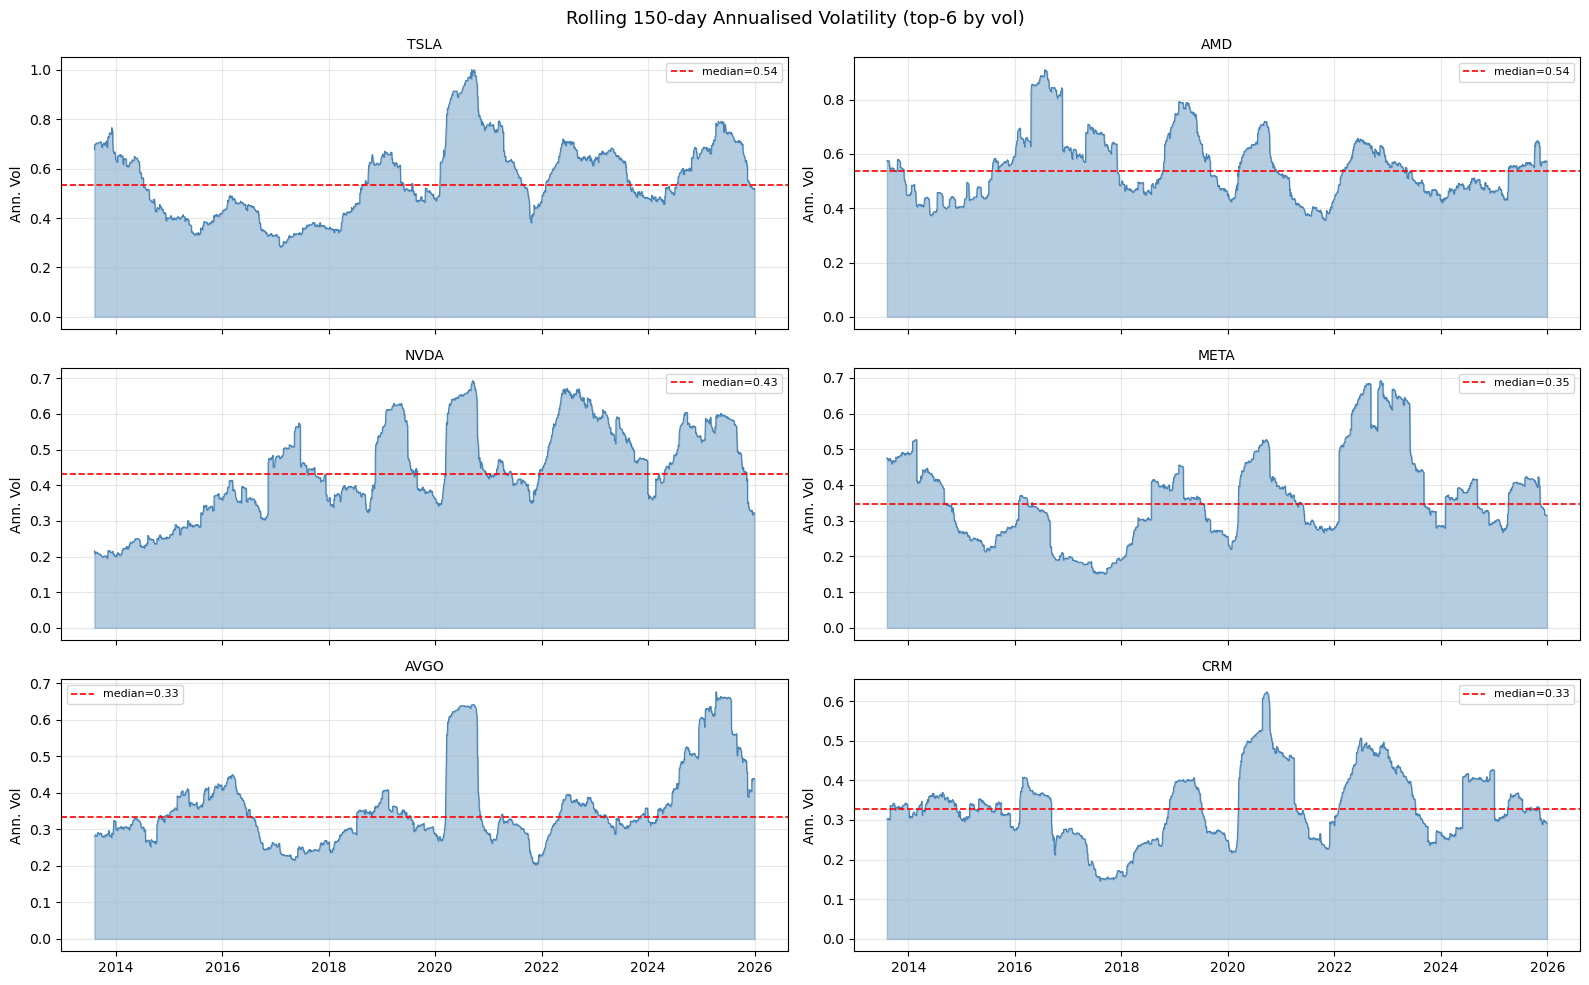

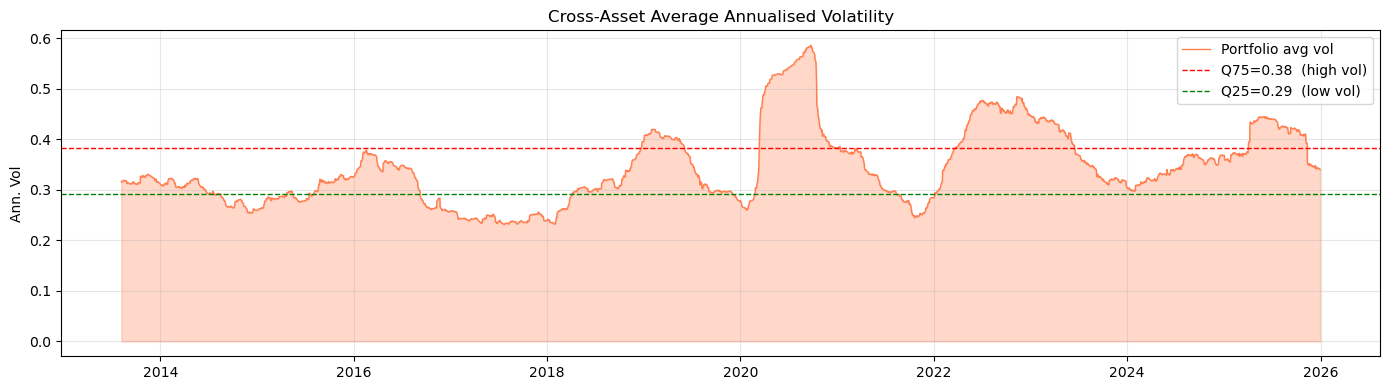

In [104]:
# ── 4.3 Rolling Volatility — Market Regime ────────────────────────────────
# ดู vol regime ของแต่ละ asset ว่า high/low vol ช่วงไหน
# annualised volatility = daily_std * sqrt(252)

# window_vol = 30
top_n      = 6
window_vol = cfg.inference.window_size
rolling_vol = log_returns.rolling(window_vol).std() * np.sqrt(252)

# Plot top-6 most volatile assets
top6 = stats_df.head(top_n).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, sym in enumerate(top6):
    vol = rolling_vol[sym].dropna()
    med = vol.median()

    axes[i].fill_between(vol.index, vol, alpha=0.4, color="steelblue")
    axes[i].plot(vol.index, vol, lw=0.8, color="steelblue")
    axes[i].axhline(med, color="red", lw=1.2, linestyle="--", label=f"median={med:.2f}")
    axes[i].set_title(sym, fontsize=10)
    axes[i].set_ylabel("Ann. Vol")
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle(f"Rolling {window_vol}-day Annualised Volatility (top-6 by vol)", fontsize=13)
plt.tight_layout()
plt.savefig(plots_dir / "rolling_vol.png", dpi=150, bbox_inches="tight")
plt.show()

# Cross-asset average vol — regime line
avg_vol = rolling_vol.mean(axis=1).dropna()
q75     = avg_vol.quantile(0.75)
q25     = avg_vol.quantile(0.25)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(avg_vol.index, avg_vol, alpha=0.3, color="coral")
ax.plot(avg_vol.index, avg_vol, lw=1, color="coral", label="Portfolio avg vol")
ax.axhline(q75, color="red",   lw=1, linestyle="--", label=f"Q75={q75:.2f}  (high vol)")
ax.axhline(q25, color="green", lw=1, linestyle="--", label=f"Q25={q25:.2f}  (low vol)")
ax.set_title("Cross-Asset Average Annualised Volatility")
ax.set_ylabel("Ann. Vol")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / "avg_vol_regime.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.4 Feature Correlation with Future Returns

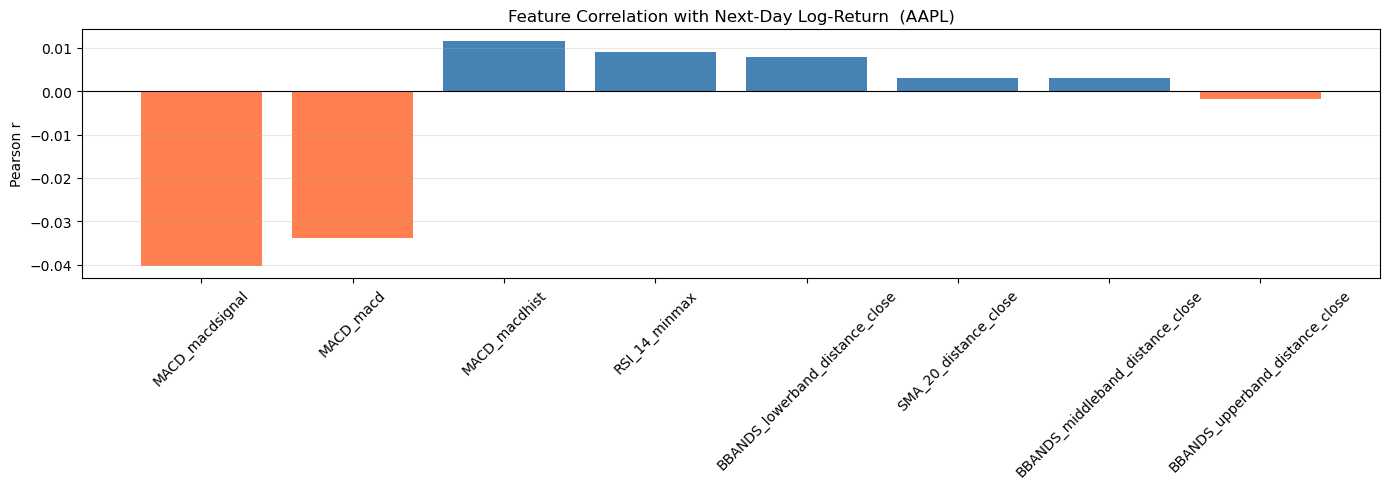


Avg |corr| with next-day return (all assets):


,avg |corr|
MACD_macdhist,0.0130
MACD_macdsignal,0.0130
BBANDS_lowerband_distance_close,0.0127
MACD_macd,0.0112
BBANDS_upperband_distance_close,0.0101
BBANDS_middleband_distance_close,0.0069
SMA_20_distance_close,0.0069
RSI_14_minmax,0.0063


In [105]:
sym = assets[0]
feat_df = df_featured.xs(sym, axis=1, level=0).copy()
ret_1d  = log_returns[[sym]].rename(columns={sym: "ret_1d"})

# Align and shift return forward 1 day (next-day return)
combined = feat_df.join(ret_1d.shift(-1)).dropna()

feat_cols = [c for c in combined.columns if c != "ret_1d" and c != "Close"]
corr_ret  = combined[feat_cols + ["ret_1d"]].corr()["ret_1d"].drop("ret_1d")
corr_ret  = corr_ret.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors   = ["steelblue" if v > 0 else "coral" for v in corr_ret.values]
ax.bar(corr_ret.index, corr_ret.values, color=colors, edgecolor="none")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Feature Correlation with Next-Day Log-Return  ({sym})", fontsize=12)
ax.set_ylabel("Pearson r")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(plots_dir / "feature_corr_nextday.png", dpi=150, bbox_inches="tight")
plt.show()

# Average across all assets
print("\nAvg |corr| with next-day return (all assets):")
corr_all = {}
for s in assets:
    try:
        fd  = df_featured.xs(s, axis=1, level=0).copy()
        rd  = log_returns[[s]].rename(columns={s: "ret_1d"})
        comb = fd.join(rd.shift(-1)).dropna()
        fc   = [c for c in comb.columns if c != "ret_1d" and c != "Close"]
        corr_all[s] = comb[fc + ["ret_1d"]].corr()["ret_1d"].drop("ret_1d").abs()
    except Exception:
        continue

avg_corr = pd.concat(corr_all.values()).groupby(level=0).mean().sort_values(ascending=False)
avg_corr.rename("avg |corr|").to_frame().to_csv(tables_dir / "feature_corr_nextday.csv")
display(avg_corr.rename("avg |corr|").to_frame().style.bar(color="steelblue").format("{:.4f}"))


### 4.5 PCA — Feature Importance & Market Mode

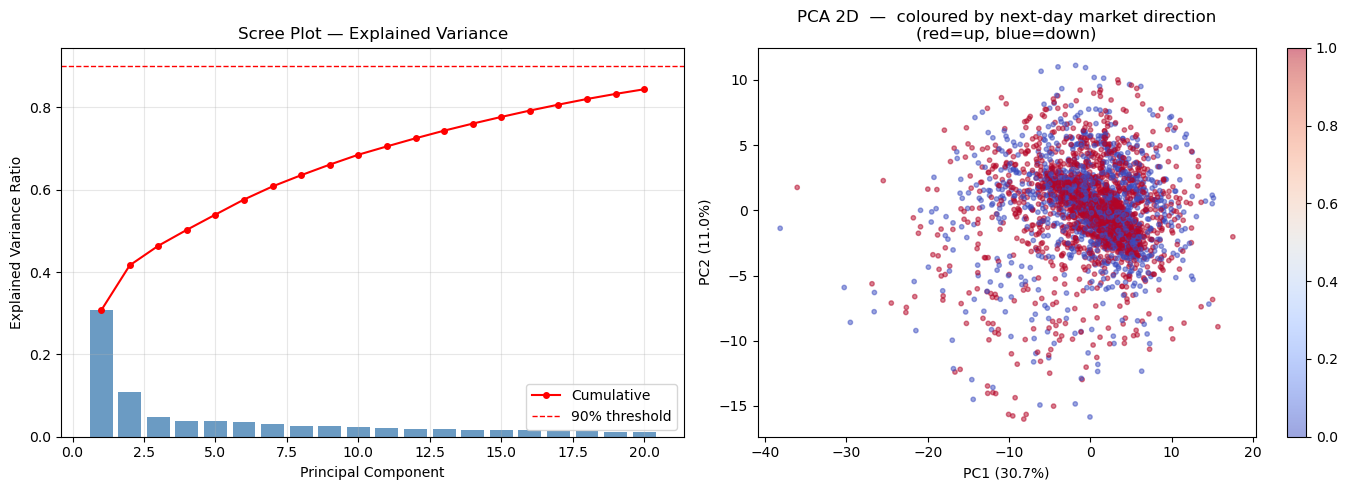

Components needed to explain 90% variance: 28
Original features: 112  →  compressed to 28  (25%)

Top-10 features driving PC1 (market mode):


,loading
GOOGL_SMA_20_distance_close,0.1365
GOOGL_BBANDS_middleband_distance_close,0.1365
GOOG_SMA_20_distance_close,0.1364
GOOG_BBANDS_middleband_distance_close,0.1364
MSFT_SMA_20_distance_close,0.1351
MSFT_BBANDS_middleband_distance_close,0.1351
NVDA_BBANDS_middleband_distance_close,0.1270
NVDA_SMA_20_distance_close,0.1270
GOOGL_BBANDS_upperband_distance_close,0.1262
AMZN_SMA_20_distance_close,0.1260


In [106]:
# ── 4.5 PCA ────────────────────────────────────────────────────────────────
# PCA บน features ทุก asset รวมกัน
# PC1 มักจะ = "Market Mode" (systematic risk ที่กระทบทุกหุ้นพร้อมกัน)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Stack features across all assets into one big matrix [T, A*F]
frames = []
for s in assets:
    try:
        fd = df_featured.xs(s, axis=1, level=0).drop(columns=["Close"], errors="ignore").dropna()
        fd.columns = [f"{s}_{c}" for c in fd.columns]
        frames.append(fd)
    except Exception:
        continue

X_all = pd.concat(frames, axis=1).dropna()
y_all = (log_returns.reindex(X_all.index).mean(axis=1).shift(-1) > 0).astype(int).reindex(X_all.index).dropna()
X_all = X_all.reindex(y_all.index)

scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X_all)

# Scree plot
pca_full = PCA().fit(X_sc)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n90      = np.argmax(cum_var >= 0.90) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20], color="steelblue", alpha=0.8)
axes[0].plot(range(1, 21), cum_var[:20], color="red", marker="o", ms=4, label="Cumulative")
axes[0].axhline(0.90, color="red", linestyle="--", lw=1, label="90% threshold")
axes[0].set_title("Scree Plot — Explained Variance")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].legend()
axes[0].grid(alpha=0.3)

# PCA 2D scatter coloured by market direction
pca2  = PCA(n_components=2).fit_transform(X_sc)
sc    = axes[1].scatter(pca2[:, 0], pca2[:, 1], c=y_all.values, cmap="coolwarm", alpha=0.5, s=10)
axes[1].set_title("PCA 2D  —  coloured by next-day market direction\n(red=up, blue=down)")
axes[1].set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]:.1%})")
plt.colorbar(sc, ax=axes[1])
plt.tight_layout()
plt.savefig(plots_dir / "pca.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Components needed to explain 90% variance: {n90}")
print(f"Original features: {X_all.shape[1]}  →  compressed to {n90}  ({n90/X_all.shape[1]:.0%})")

# Top contributing features to PC1
loadings = pd.Series(np.abs(pca_full.components_[0]), index=X_all.columns).sort_values(ascending=False)
loadings.head(20).rename("loading").to_frame().to_csv(tables_dir / "pca_loadings.csv")

pd.DataFrame([{
    "n_components_90pct" : n90,
    "total_features"     : X_all.shape[1],
    "pc1_explained_var"  : pca_full.explained_variance_ratio_[0],
    "top_feature_pc1"    : loadings.index[0],
}]).to_csv(tables_dir / "pca_summary.csv", index=False)

print("\nTop-10 features driving PC1 (market mode):")
display(loadings.head(10).rename("loading").to_frame().style.bar(color="steelblue").format("{:.4f}"))


### 4.6 t-SNE — Market Regime Clustering

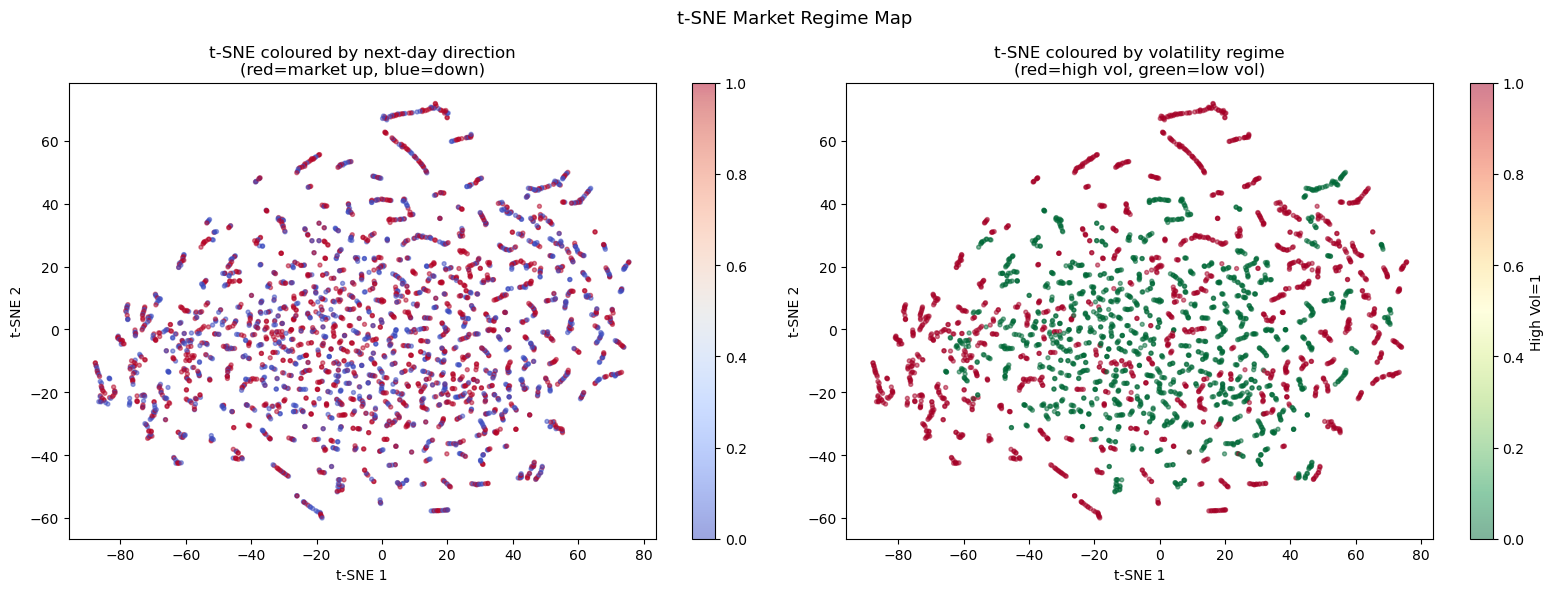

In [107]:
# ── 4.6 t-SNE — Market Regime Clustering ─────────────────────────────────
# ดูว่า feature space มี cluster อะไรบ้าง (high-vol vs low-vol, bull vs bear)
# ใช้ PCA ลดมิติก่อน แล้วค่อยยิง t-SNE เพื่อความเร็ว

from sklearn.manifold import TSNE

# ใช้ PCA n90 components ก่อน
X_pca_n90 = PCA(n_components=min(n90, 50)).fit_transform(X_sc)

tsne   = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=cfg.random_seed)
X_tsne = tsne.fit_transform(X_pca_n90)

# Colour by: 1) market direction  2) rolling volatility regime
avg_vol_aligned = rolling_vol.mean(axis=1).reindex(y_all.index)
vol_regime      = (avg_vol_aligned > avg_vol_aligned.median()).astype(int)  # 1=high, 0=low

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_all.values,
                       cmap="coolwarm", alpha=0.5, s=8)
axes[0].set_title("t-SNE coloured by next-day direction\n(red=market up, blue=down)")
plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=vol_regime.values,
                       cmap="RdYlGn_r", alpha=0.5, s=8)
axes[1].set_title("t-SNE coloured by volatility regime\n(red=high vol, green=low vol)")
plt.colorbar(sc2, ax=axes[1], label="High Vol=1")

for ax in axes:
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")

plt.suptitle("t-SNE Market Regime Map", fontsize=13)
plt.tight_layout()
plt.savefig(plots_dir / "tsne.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.7 UMAP — Global Structure

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


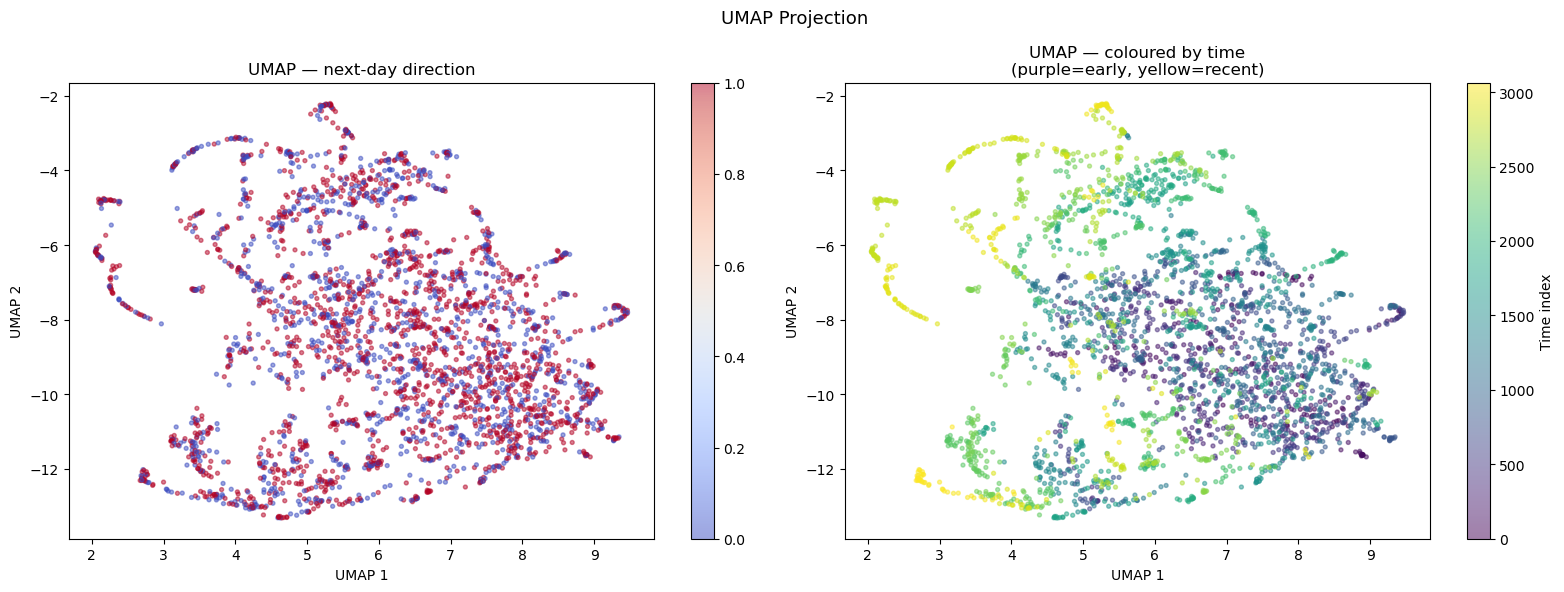

In [108]:
# ── 4.7 UMAP ──────────────────────────────────────────────────────────────
# UMAP เร็วกว่า t-SNE และ preserve global structure ได้ดีกว่า
# เหมาะดู regime transitions (จาก bull → bear → recovery)

try:
    import umap

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=cfg.random_seed)
    X_umap  = reducer.fit_transform(X_pca_n90)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sc1 = axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=y_all.values,
                           cmap="coolwarm", alpha=0.5, s=8)
    axes[0].set_title("UMAP — next-day direction")
    plt.colorbar(sc1, ax=axes[0])

    # Colour by time (to see trajectory through feature space)
    time_idx = np.arange(len(X_umap))
    sc2 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=time_idx,
                           cmap="viridis", alpha=0.5, s=8)
    axes[1].set_title("UMAP — coloured by time\n(purple=early, yellow=recent)")
    plt.colorbar(sc2, ax=axes[1], label="Time index")

    for ax in axes:
        ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")

    plt.suptitle("UMAP Projection", fontsize=13)
    plt.tight_layout()
    plt.savefig(plots_dir / "umap.png", dpi=150, bbox_inches="tight")
    plt.show()

except ImportError:
    print("umap-learn not installed. Run:  pip install umap-learn")


### 4.8 Summary — Feature Selection Insights

In [109]:
# ── 4.8 Summary ───────────────────────────────────────────────────────────
# รวม insight ทั้งหมดเป็น table เพื่อ inform feature selection ตอน train

print("=" * 60)
print("FEATURE ANALYSIS SUMMARY")
print("=" * 60)

print(f"\n[Assets]  {len(assets)} assets  |  {len(log_returns)} trading days")
print(f"  Most volatile  : {stats_df['Std'].idxmax()}  (σ={stats_df['Std'].max():.4f})")
print(f"  Least volatile : {stats_df['Std'].idxmin()}  (σ={stats_df['Std'].min():.4f})")

print(f"\n[Correlation]")
if pairs:
    print(f"  {len(pairs)} highly correlated pairs (|r|>0.85) — consider dropping redundant assets")
else:
    print("  No highly correlated pairs — good diversity")

print(f"\n[PCA]")
print(f"  PC1 explains {pca_full.explained_variance_ratio_[0]:.1%} of variance (market mode)")
print(f"  {n90} components needed for 90% variance  (out of {X_all.shape[1]} features)")
print(f"  Top feature driving PC1: {loadings.index[0]}")

print(f"\n[Predictive Signal]")
top_feat = avg_corr.index[0]
print(f"  Highest avg |corr| with next-day return: {top_feat}  ({avg_corr.iloc[0]:.4f})")
print(f"  → Use as priority feature in cond")

print("\n[Recommendation]")
print("  1. Keep all indicators — PCA shows they contribute distinct variance")
print("  2. Watch highly correlated asset pairs for portfolio construction")
print(f"  3. {n90} PCA dims capture 90% info — model doesn't need all raw features")
print("  4. t-SNE/UMAP show separable regimes — model should learn regime-aware generation")


FEATURE ANALYSIS SUMMARY

[Assets]  14 assets  |  3268 trading days
  Most volatile  : TSLA  (σ=0.0363)
  Least volatile : CSCO  (σ=0.0154)

[Correlation]
  1 highly correlated pairs (|r|>0.85) — consider dropping redundant assets

[PCA]
  PC1 explains 30.7% of variance (market mode)
  28 components needed for 90% variance  (out of 112 features)
  Top feature driving PC1: GOOGL_SMA_20_distance_close

[Predictive Signal]
  Highest avg |corr| with next-day return: MACD_macdhist  (0.0130)
  → Use as priority feature in cond

[Recommendation]
  1. Keep all indicators — PCA shows they contribute distinct variance
  2. Watch highly correlated asset pairs for portfolio construction
  3. 28 PCA dims capture 90% info — model doesn't need all raw features
  4. t-SNE/UMAP show separable regimes — model should learn regime-aware generation


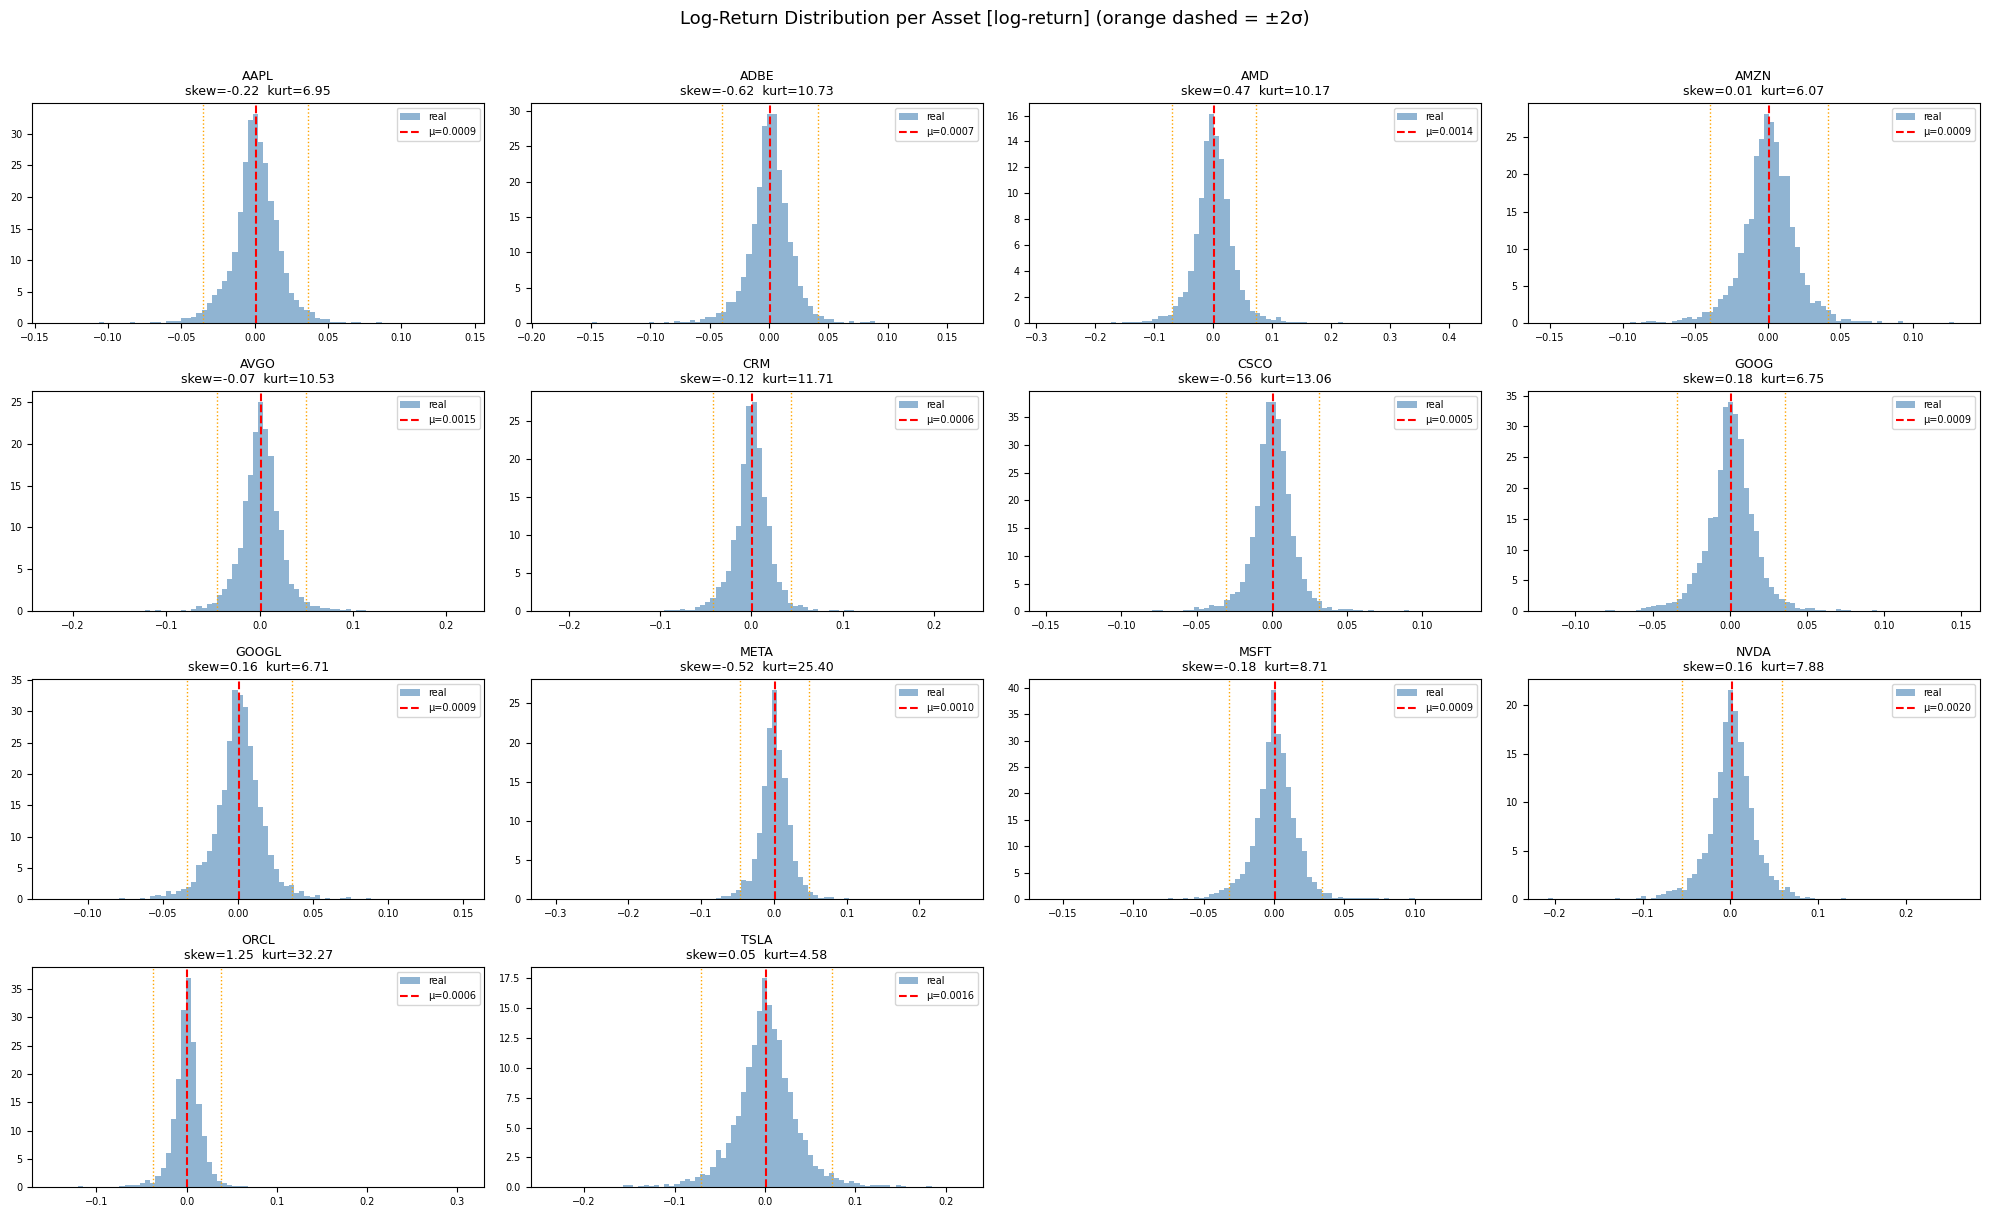

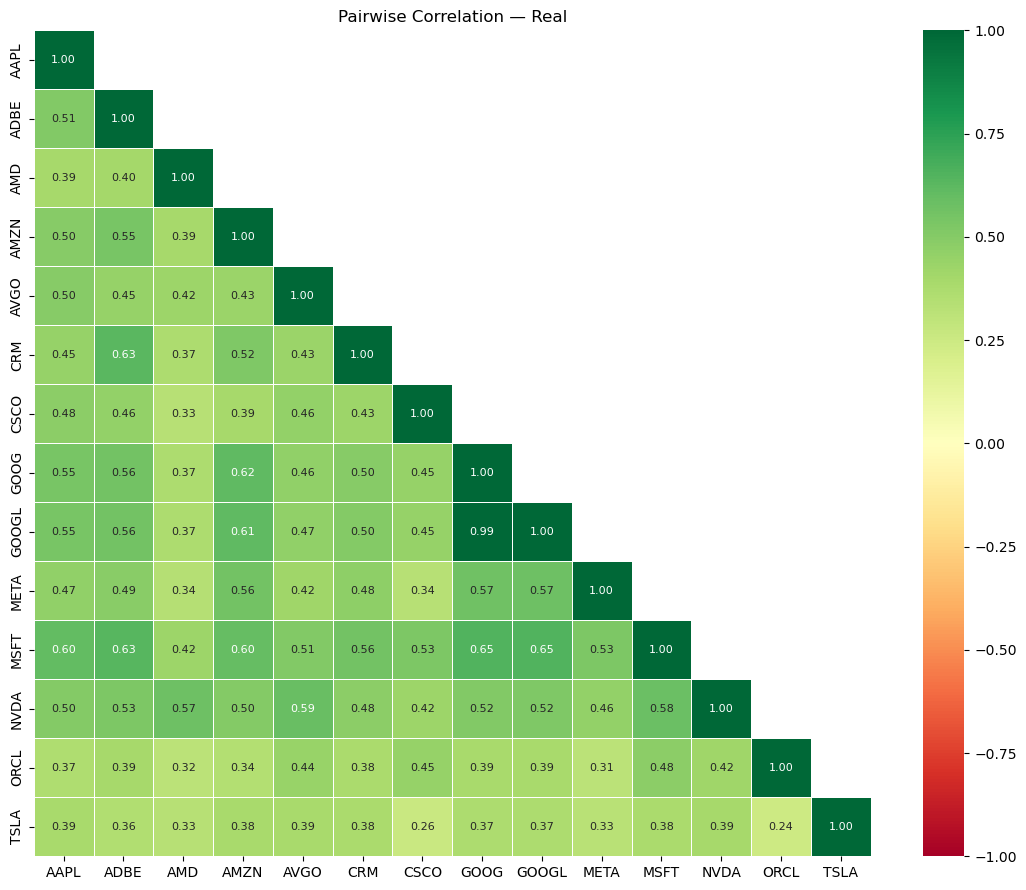


Highly correlated pairs (|r| > 0.85):


,Asset A,Asset B,r
0,GOOG,GOOGL,0.995


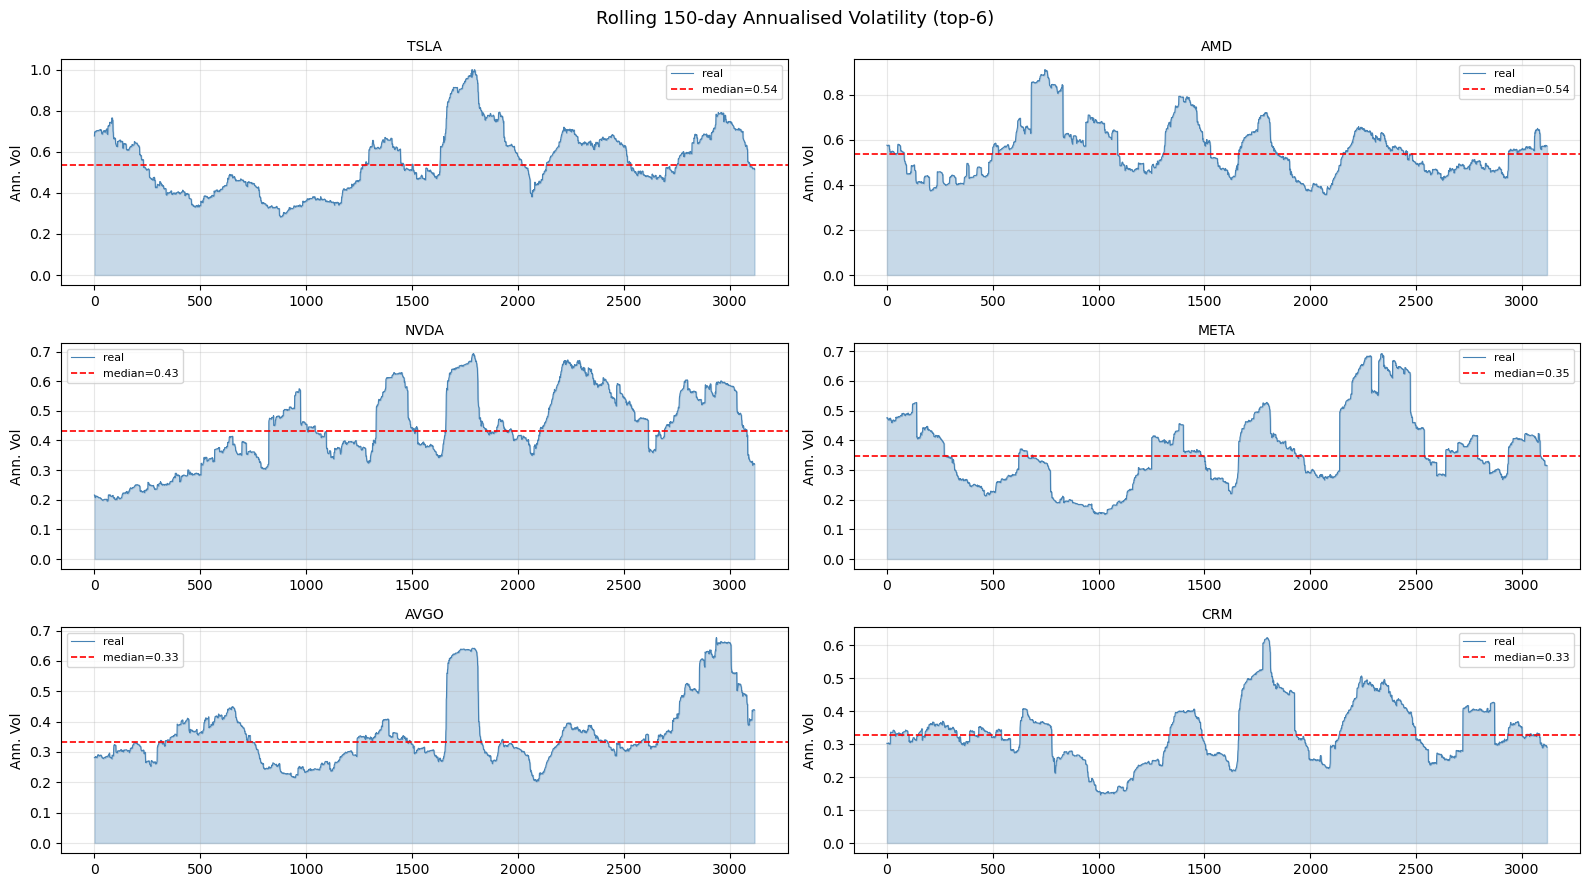

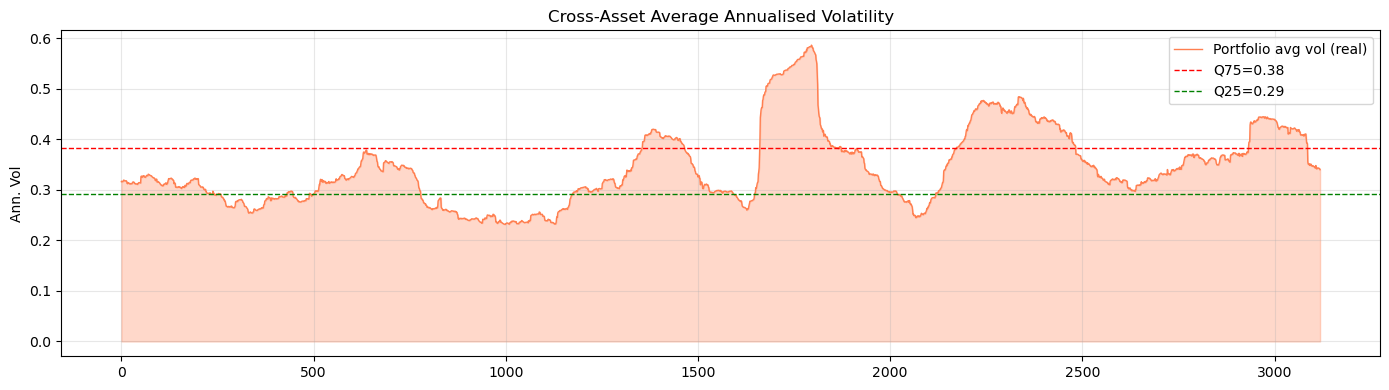

In [110]:
fig = plot_return_dist(np.asarray(log_returns), assets)
fig.savefig(plots_dir / "return_dist_util.png", dpi=150, bbox_inches="tight")

fig, corr_df = plot_correlation(np.asarray(log_returns), assets)
fig.savefig(plots_dir / "correlation.png", dpi=150, bbox_inches="tight")

fig1, fig2 = plot_rolling_vol(np.asarray(log_returns), assets, window=cfg.inference.window_size)
fig1.savefig(plots_dir / "rolling_vol_per_asset.png", dpi=150, bbox_inches="tight")
fig2.savefig(plots_dir / "rolling_vol_avg.png",       dpi=150, bbox_inches="tight")


### 4.9 Comparison plot (Noisy log reuturns)

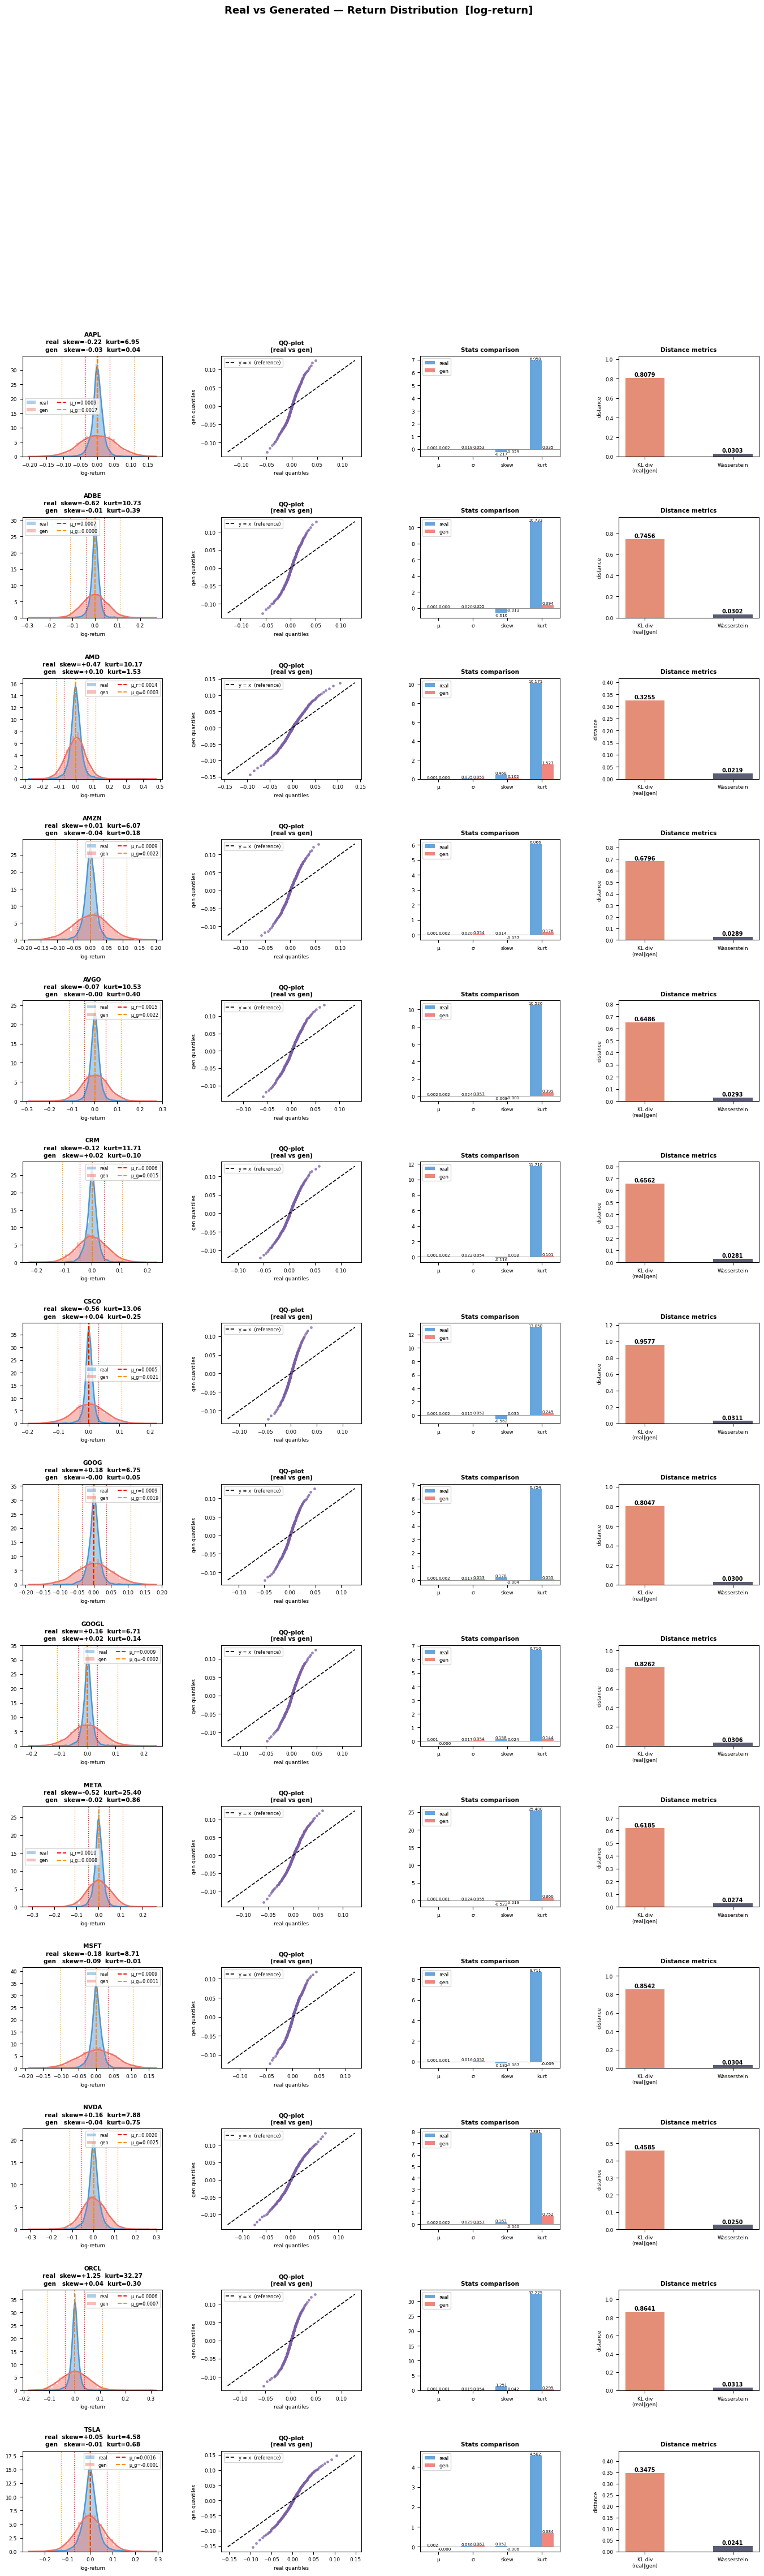

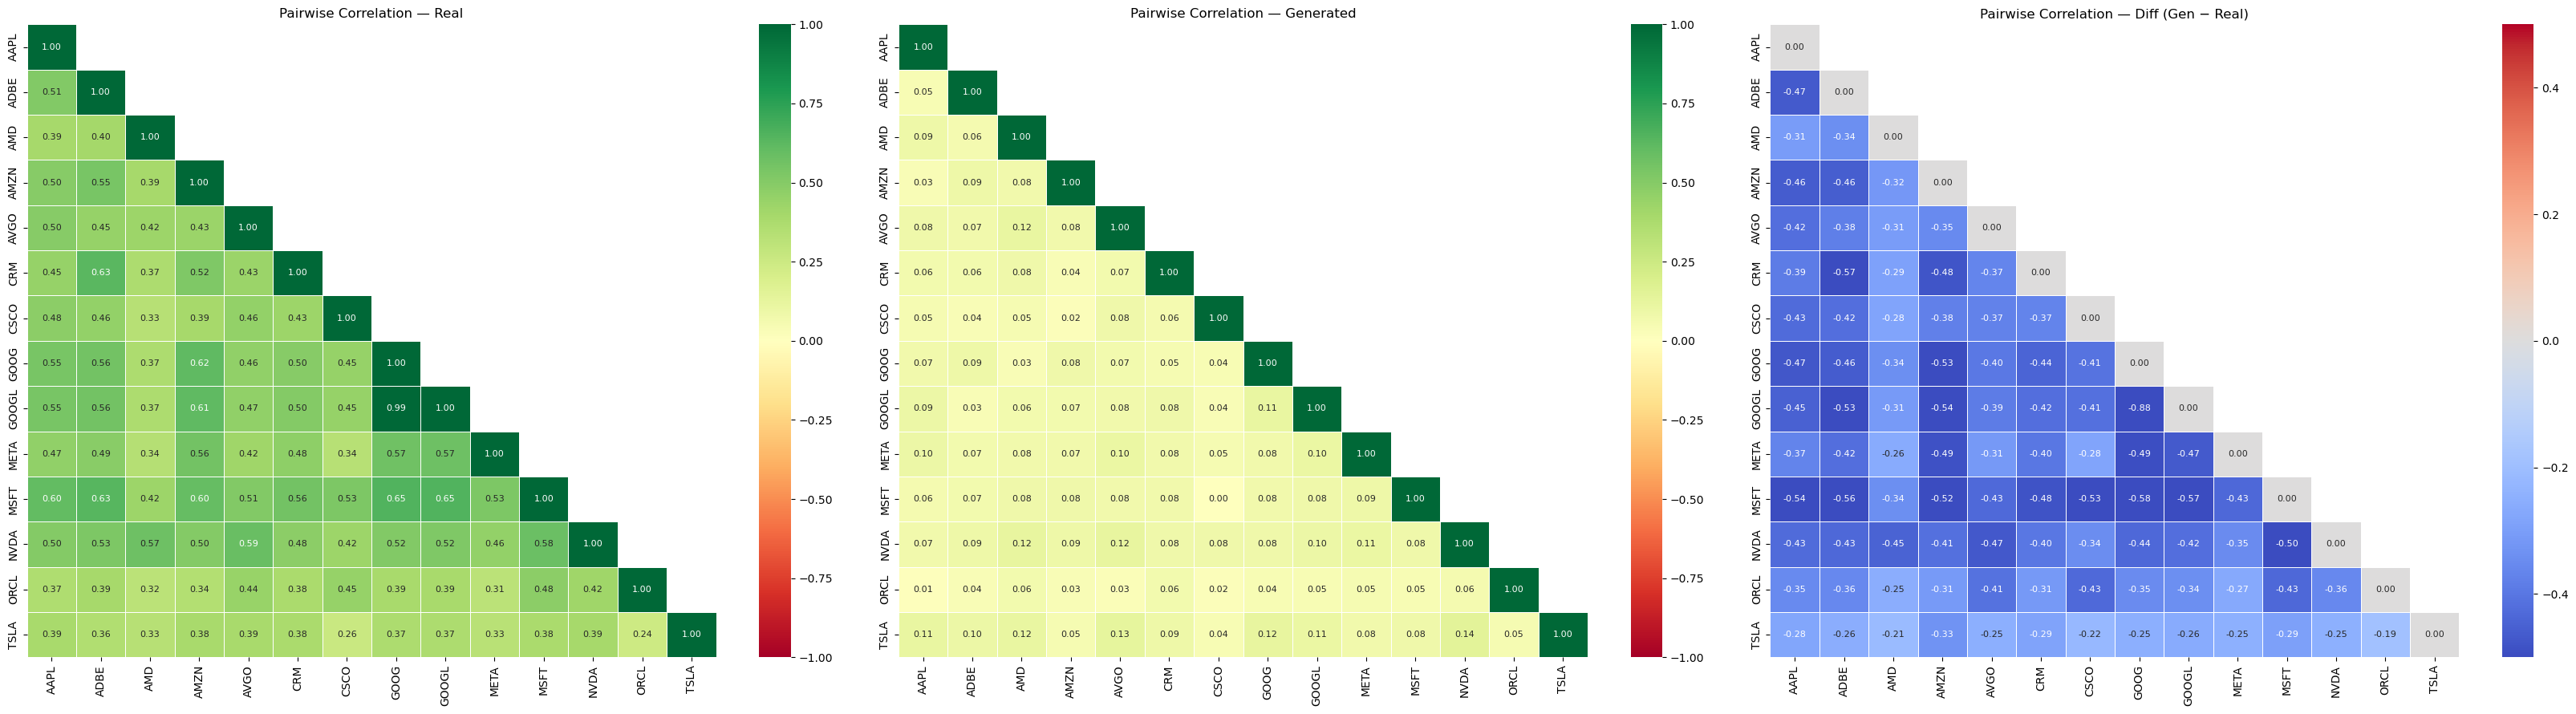


Pairs ที่ |r| > 0.85 ในอย่างน้อยหนึ่ง set:


,Asset A,Asset B,r_real,r_gen,delta
0,GOOG,GOOGL,0.995,0.11,-0.885


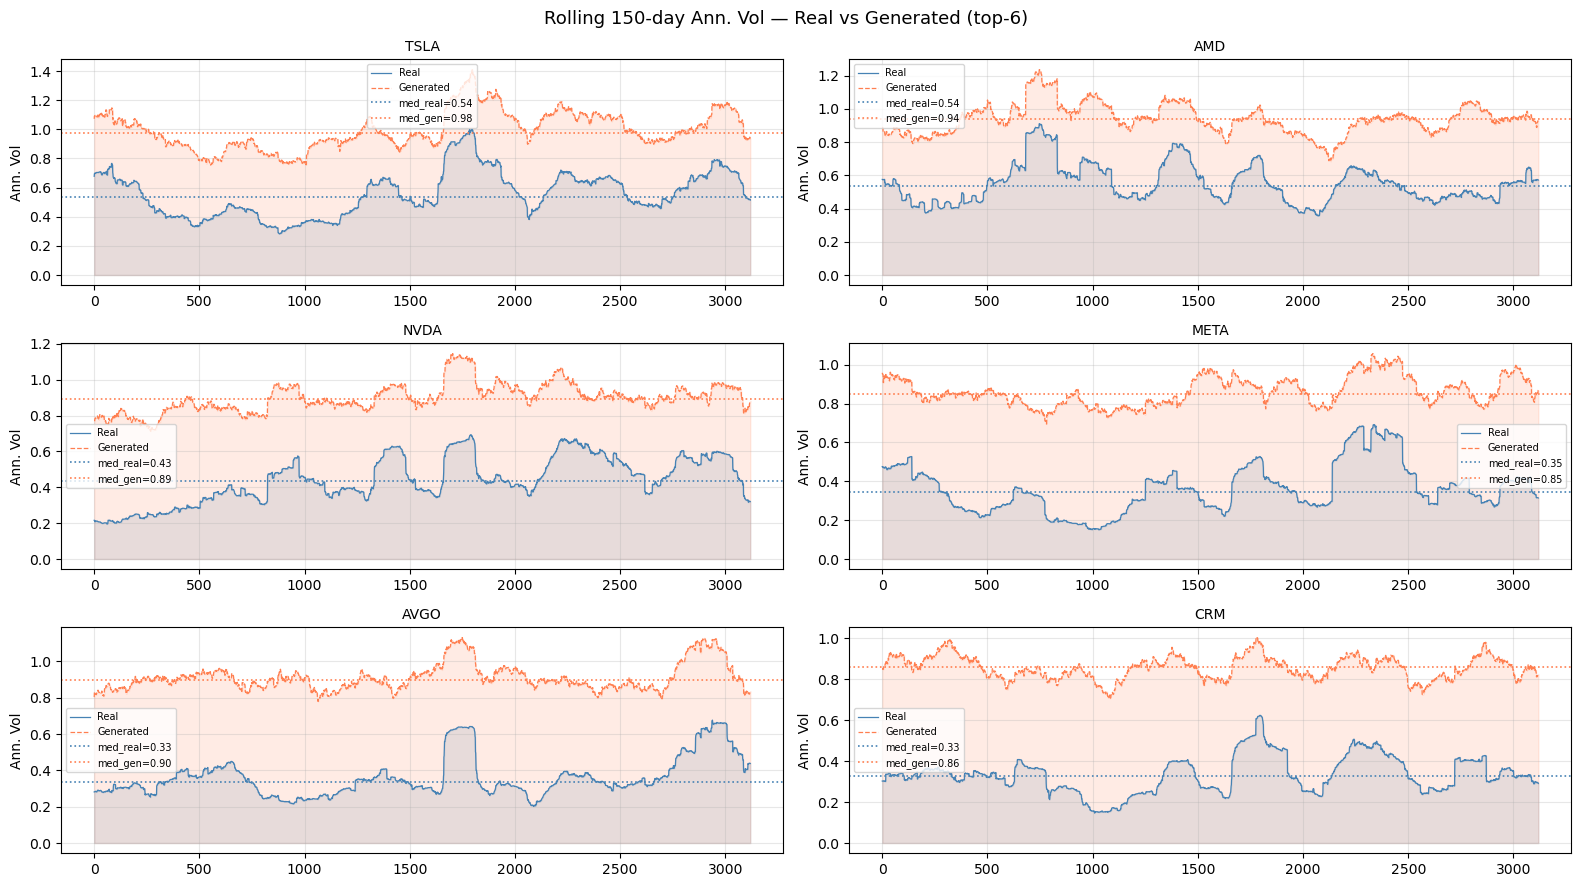

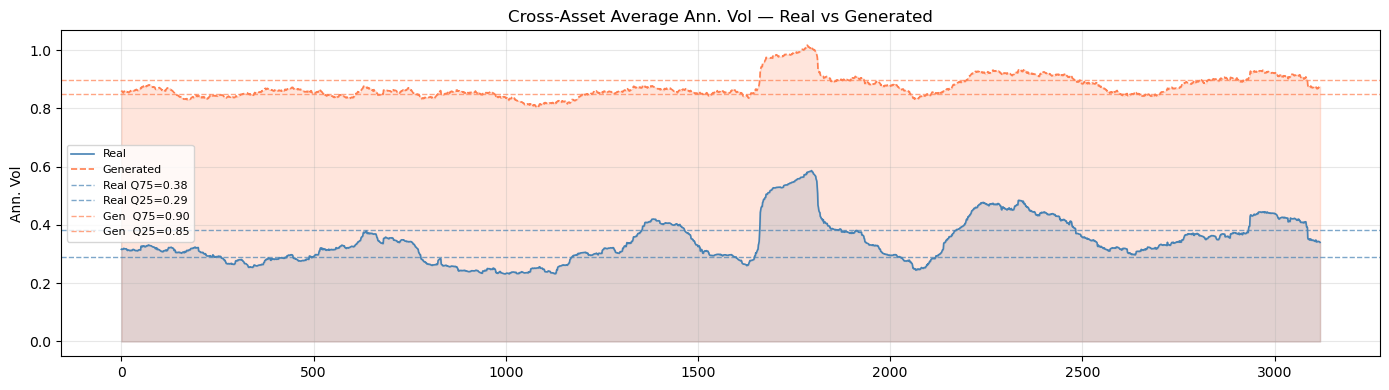

In [111]:
noise_level = 0.05
noise = np.random.normal(loc=0.0, scale=noise_level, size=log_returns.shape)
new_log_returns = log_returns + noise

# Compare plots (noise test)
fig, dist_df = plot_compare_dist(np.asarray(log_returns), np.asarray(new_log_returns), assets)
fig.savefig(plots_dir / "noise_test_compare_dist.png", dpi=150, bbox_inches="tight")
dist_df.to_csv(tables_dir / "compare_dist_stats.csv")

fig, corr_real, corr_gen = plot_compare_correlation(np.asarray(log_returns), np.asarray(new_log_returns), assets)
fig.savefig(plots_dir / "noise_test_compare_correlation.png", dpi=150, bbox_inches="tight")
corr_real.to_csv(tables_dir / "return_correlation.csv")

fig1, fig2 = plot_compare_rolling_vol(np.asarray(log_returns), np.asarray(new_log_returns), assets, window=cfg.inference.window_size)
fig1.savefig(plots_dir / "noise_test_compare_rolling_vol_per_asset.png", dpi=150, bbox_inches="tight")
fig2.savefig(plots_dir / "noise_test_compare_rolling_vol_avg.png",       dpi=150, bbox_inches="tight")

## 5. Sequence Builder

In [112]:
def to_log_return(
    df: pd.DataFrame,
    target_feature_name: str,
    drop_ohlcv: bool = True,
) -> pd.DataFrame:
    close = df.xs(target_feature_name, axis=1, level=0)
    log_return = np.log(close / close.shift(1))

    log_cols = pd.MultiIndex.from_tuples(
        [(asset, "Log_Returns") for asset in log_return.columns]
    )
    df_log = pd.DataFrame(log_return.values, index=df.index, columns=log_cols)

    if drop_ohlcv:
        result = df_log
    else:
        result = pd.concat([df, df_log], axis=1).sort_index(axis=1)

    return result.dropna() # Drop first row

def create_sequences(
    df: pd.DataFrame,
    target_feature_name: str,
    horizon: int,
    mode: str = "backward"
) -> pd.DataFrame:
    tgt = df.xs(target_feature_name, level=1, axis=1)
    seqs = []
    for step in range(horizon + 1):
        shifted = tgt.shift(-step if mode == "forward" else step)
        shifted.columns = pd.MultiIndex.from_tuples(
            [(col, f"D{step}") for col in shifted.columns]
        )
        seqs.append(shifted)

    result = pd.concat(seqs, axis=1)
    result = result.reindex(
        sorted(result.columns, key=lambda c: (c[0], int(c[1][1:]))),
        axis=1
    )
    return result

In [113]:
df_log_return = to_log_return(df, "Close", True)
df_log_return

,AAPL,ADBE,AMD,AMZN,AVGO,CRM,CSCO,GOOG,GOOGL,META,MSFT,NVDA,ORCL,TSLA
,Log_Returns,Log_Returns,Log_Returns,Log_Returns,Log_Returns,Log_Returns,Log_Returns,Log_Returns,Log_Returns,Log_Returns,Log_Returns,Log_Returns,Log_Returns,Log_Returns
Date,,,,,,,,,,,,,,
2013-01-03,-0.012703,-0.015508,-0.015937,0.004537,0.005211,-0.014476,0.005393,0.000581,0.000581,-0.008248,-0.013487,0.000786,-0.011015,-0.016826
2013-01-04,-0.028250,0.010016,0.039375,0.002589,-0.006441,0.005320,0.001466,0.019568,0.019568,0.035029,-0.018893,0.032460,0.008706,-0.010699
2013-01-07,-0.005900,-0.004995,0.030421,0.035295,-0.005553,-0.003721,-0.009321,-0.004373,-0.004373,0.022689,-0.001872,-0.029323,-0.005214,-0.001746
2013-01-08,0.002687,0.005258,0.000000,-0.007778,-0.006831,0.005842,0.000985,-0.001975,-0.001975,-0.012312,-0.005259,-0.022170,0.000290,-0.019407
2013-01-09,-0.015752,0.013542,-0.015095,-0.000113,0.021877,0.010884,-0.000492,0.006551,0.006552,0.051311,0.005634,-0.022673,0.000580,-0.001188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,0.005117,-0.014396,-0.000233,0.016111,0.022787,-0.004545,-0.001153,0.013876,0.014645,0.005187,0.003972,0.029608,-0.015443,-0.006507
2025-12-24,0.005310,0.001588,0.000651,0.001033,0.002573,0.006923,0.000000,-0.000032,-0.000827,0.003918,0.002400,-0.003176,0.010946,-0.000330


In [114]:
df_seq = create_sequences(df_log_return, feature_target, sequence_depth, sequence_mode)
df_seq

AAPL                                                    \
                  D0        D1        D2        D3        D4        D5   
Date                                                                     
2013-01-03 -0.012703       NaN       NaN       NaN       NaN       NaN   
2013-01-04 -0.028250 -0.012703       NaN       NaN       NaN       NaN   
2013-01-07 -0.005900 -0.028250 -0.012703       NaN       NaN       NaN   
2013-01-08  0.002687 -0.005900 -0.028250 -0.012703       NaN       NaN   
2013-01-09 -0.015752  0.002687 -0.005900 -0.028250 -0.012703       NaN   
...              ...       ...       ...       ...       ...       ...   
2025-12-23  0.005117 -0.009915  0.005423  0.001287 -0.010138  0.001822   
2025-12-24  0.005310  0.005117 -0.009915  0.005423  0.001287 -0.010138   
2025-12-26 -0.001498  0.005310  0.005117 -0.009915  0.005423  0.001287   
2025-12-29  0.001316 -0.001498  0.005310  0.005117 -0.009915  0.005423   
2025-12-30 -0.002487  0.001316 -0.001498  0.005310  0.005117 -0.009915   

                                                    ...      TSLA            \
                  D6        D7        D8        D9  ...      D171      D172   
Date                                                ...                       
2013-01-03       NaN       NaN       NaN       NaN  ...       NaN       NaN   
2013-01-04       NaN       NaN       NaN       NaN  ...       NaN       NaN   
2013-01-07       NaN       NaN       NaN       NaN  ...       NaN       NaN   
2013-01-08       NaN       NaN       NaN       NaN  ...       NaN       NaN   
2013-01-09       NaN       NaN       NaN       NaN  ...       NaN       NaN   
...              ...       ...       ...       ...  ...       ...       ...   
2025-12-23 -0.015098  0.000899 -0.002694  0.005756  ... -0.059181 -0.000745   
2025-12-24  0.001822 -0.015098  0.000899 -0.002694  ...  0.044994 -0.059181   
2025-12-26 -0.010138  0.001822 -0.015098  0.000899  ...  0.052272  0.044994   
2025-12-29  0.001287 -0.010138  0.001822 -0.015098  ...  0.034379  0.052272   
2025-12-30  0.005423  0.001287 -0.010138  0.001822  ...  0.093518  0.034379   

                                                                        \
                D173      D174      D175      D176      D177      D178   
Date                                                                     
2013-01-03       NaN       NaN       NaN       NaN       NaN       NaN   
2013-01-04       NaN       NaN       NaN       NaN       NaN       NaN   
2013-01-07       NaN       NaN       NaN       NaN       NaN       NaN   
2013-01-08       NaN       NaN       NaN       NaN       NaN       NaN   
2013-01-09       NaN       NaN       NaN       NaN       NaN       NaN   
...              ...       ...       ...       ...       ...       ...   
2025-12-23 -0.050691  0.006950  0.000159 -0.000357 -0.075522  0.204491   
2025-12-24 -0.000745 -0.050691  0.006950  0.000159 -0.000357 -0.075522   
2025-12-26 -0.059181 -0.000745 -0.050691  0.006950  0.000159 -0.000357   
2025-12-29  0.044994 -0.059181 -0.000745 -0.050691  0.006950  0.000159   
2025-12-30  0.052272  0.044994 -0.059181 -0.000745 -0.050691  0.006950   

                                
                D179      D180  
Date                            
2013-01-03       NaN       NaN  
2013-01-04       NaN       NaN  
2013-01-07       NaN       NaN  
2013-01-08       NaN       NaN  
2013-01-09       NaN       NaN  
...              ...       ...  
2025-12-23 -0.050236 -0.025979  
2025-12-24  0.204491 -0.050236  
2025-12-26 -0.075522  0.204491  
2025-12-29 -0.000357 -0.075522  
2025-12-30  0.000159 -0.000357  

[3268 rows x 2534 columns]

In [115]:
# Check NaN values
df_seq.isna().sum().groupby(level=1).first().rename_axis("depth").reset_index(name="nan_count").assign(depth_num=lambda x: x["depth"].str[1:].astype(int)).sort_values("depth_num").drop(columns="depth_num").reset_index(drop=True)

,depth,nan_count
0,D0,0
1,D1,1
2,D2,2
3,D3,3
4,D4,4
...,...,...
176,D176,176
177,D177,177
178,D178,178
179,D179,179


Total NaN: 22092


Price,RSI_14_minmax,SMA_20_distance_close,MACD_macd,MACD_macdsignal,MACD_macdhist,BBANDS_upperband_distance_close,BBANDS_middleband_distance_close,BBANDS_lowerband_distance_close
AAPL,199,191,205,205,205,191,191,191
ADBE,199,191,205,205,205,191,191,191
AMD,199,191,205,205,205,191,191,191
AMZN,199,191,205,205,205,191,191,191
AVGO,199,191,205,205,205,191,191,191
CRM,199,191,205,205,205,191,191,191
CSCO,199,191,205,205,205,191,191,191
GOOG,199,191,205,205,205,191,191,191
GOOGL,199,191,205,205,205,191,191,191
META,199,191,205,205,205,191,191,191


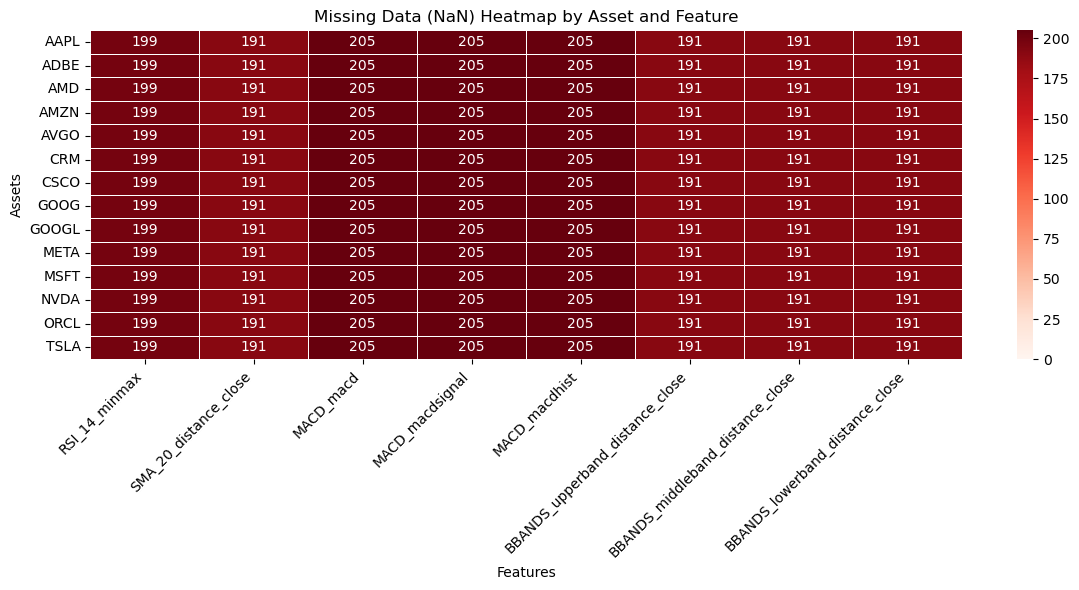

In [116]:
missing_summary = summarize_missing_features(df_featured)
missing_summary.to_csv(tables_dir / "missing_data_each_feature.csv")

## 5  Prepare Arrays  (`x`, `cond`, `original`, `dates`)

In [117]:
print(f"df: {df.shape}")
print(f"df_seq: {df_seq.shape} (-1 row because use to calculating log returns)")
print(f"df_featured: {df_featured.shape}")

# ── Align index across all dataframes ─────────────────────────────────
df_seq = df_seq.dropna()
df_featured = df_featured.dropna()

common_idx  = df_seq.index.intersection(df_featured.index) # using df_seq and df_featured reference

df = df.loc[common_idx]
df_seq      = df_seq.loc[common_idx]
df_featured = df_featured.loc[common_idx]

print(10 * "-")
print(f"df: {df.shape}")
print(f"df_seq: {df_seq.shape}")
print(f"df_featured: {df_featured.shape}")

x_asset = df_seq.columns.get_level_values(0).nunique()
x_feature = df_seq.columns.get_level_values(1).nunique()
x = df_seq.values.reshape(-1, x_asset, x_feature)   # [T, A, F]

cond_asset   = df_featured.columns.get_level_values(0).nunique()
cond_feature = df_featured.columns.get_level_values(1).nunique()
cond = df_featured.values.reshape(-1, cond_asset, cond_feature)   # [T, A, F_cond]

ohlcv_asset   = df.columns.get_level_values(1).nunique()
ohlcv_feature = df.columns.get_level_values(0).nunique()
ohlcv = df.values.reshape(-1, ohlcv_asset, ohlcv_feature)

dates = df.index.to_numpy()

print(f"x        : {x.shape}")
print(f"cond     : {cond.shape}")
print(f"ohlcv    : {ohlcv.shape}")
print(f"dates    : {dates.shape}")

df: (3269, 70)
df_seq: (3268, 2534) (-1 row because use to calculating log returns)
df_featured: (3269, 112)
----------
df: (3064, 70)
df_seq: (3064, 2534)
df_featured: (3064, 112)
x        : (3064, 14, 181)
cond     : (3064, 14, 8)
ohlcv    : (3064, 14, 5)
dates    : (3064,)


---
## 6  Train / Val / Test Split

Uses a **time-series aware** split with a *gap* of `steps_sim` rows
between each set to prevent look-ahead leakage.


In [ ]:
def calc_ts_splits(
    total: int,
    ratios: list[float],
    gap: int,
) -> tuple[tuple, tuple, tuple]:
    """
    Return (train, val, test) index ranges with gap buffers.

    Example
    -------
    >>> calc_ts_splits(1000, [0.8, 0.1, 0.1], gap=20)
    # Train [0:768], Val [788:864], Test [884:1000]
    """
    usable = total - gap * 2
    if usable <= 0:
        raise ValueError("gap is larger than the dataset")

    n_train = math.floor(usable * ratios[0])
    n_val   = math.floor(usable * ratios[1])
    n_test  = usable - n_train - n_val

    t_s, t_e = 0,              n_train
    v_s, v_e = t_e + gap,      t_e + gap + n_val
    te_s, te_e = v_e + gap,    total

    print(f"Total: {total}  |  Gap: {gap}")
    print(f"  Train : [{t_s}:{t_e}]  ({n_train} samples)")
    print(f"  Gap1  : [{t_e}:{v_s}]  (discarded)")
    print(f"  Val   : [{v_s}:{v_e}]  ({n_val} samples)")
    print(f"  Gap2  : [{v_e}:{te_s}]  (discarded)")
    print(f"  Test  : [{te_s}:{te_e}]  ({n_test} samples)")

    return (t_s, t_e), (v_s, v_e), (te_s, te_e)


def calc_ts_splits_fixed_test(
    dates: np.ndarray,
    test_start_date: str,
    test_end_date: str,
    val_ratio: float = 0.1,
    gap: int = 150,
) -> tuple[tuple, tuple, tuple]:
    """
    Split by FIXED test date range, with gap buffers.
    Remaining data is split by ratio into train/val.

    Parameters
    ----------
    dates : np.ndarray
        Array of datetime64 objects
    test_start_date : str
        Test period start, e.g. "2024-01-01"
    test_end_date : str
        Test period end, e.g. "2025-12-31"
    val_ratio : float
        Fraction of remaining-after-test to use for val (default 0.1)
    gap : int
        Rows to discard between splits (default 150)

    Returns
    -------
    (t_s, t_e), (v_s, v_e), (te_s, te_e)
        Index ranges for train, val, test
    """
    dates_pd = pd.to_datetime(dates)
    test_start = pd.to_datetime(test_start_date)
    test_end = pd.to_datetime(test_end_date)

    # Find test indices
    test_mask = (dates_pd >= test_start) & (dates_pd <= test_end)
    test_indices = np.where(test_mask)[0]

    if len(test_indices) == 0:
        raise ValueError(f"No dates found in range [{test_start_date}, {test_end_date}]")

    te_s = test_indices[0]
    te_e = test_indices[-1] + 1  # exclusive end

    # Remaining before test: split into train/val with gap
    remaining = te_s - gap
    if remaining <= 0:
        raise ValueError("Not enough data before test period (accounting for gap)")

    n_val = max(1, math.floor(remaining * val_ratio))
    n_train = remaining - n_val - gap

    if n_train <= 0:
        raise ValueError("Not enough data for train split")

    t_s, t_e = 0, n_train
    v_s, v_e = t_e + gap, t_e + gap + n_val

    print(f"Total rows: {len(dates)}  |  Gap: {gap}")
    print(f"  Train : [{t_s}:{t_e}]  ({n_train} samples)  |  {pd.to_datetime(dates[t_s]).date()} → {pd.to_datetime(dates[t_e-1]).date()}")
    print(f"  Gap1  : [{t_e}:{v_s}]  (discarded)")
    print(f"  Val   : [{v_s}:{v_e}]  ({n_val} samples)   |  {pd.to_datetime(dates[v_s]).date()} → {pd.to_datetime(dates[v_e-1]).date()}")
    print(f"  Gap2  : [{v_e}:{te_s}]  (discarded)")
    print(f"  Test  : [{te_s}:{te_e}]  ({te_e - te_s} samples) |  {pd.to_datetime(dates[te_s]).date()} → {pd.to_datetime(dates[te_e-1]).date()}")

    return (t_s, t_e), (v_s, v_e), (te_s, te_e)


def split_arrays(
    x: Annotated[np.ndarray, ("n_lengths", "n_assets", "n_channels")],
    cond: Annotated[np.ndarray, ("n_lengths", "n_assets", "n_channels")],
    ohlcv: Annotated[np.ndarray, ("n_lengths", "n_assets", "n_channels")],
    dates: Annotated[np.ndarray, ("n_lengths")],
    ratios: list[float],
    gap: int,
    ohlcv_fields: list[float],
):
    """Split all arrays consistently and return 3 part-dicts."""
    total = x.shape[0]
    close_idx = ohlcv_fields.index("Close")
    close = ohlcv[:, :, close_idx]        # [T, Assets]  — price for portfolio eval

    (t_s, t_e), (v_s, v_e), (te_s, te_e) = calc_ts_splits(total, ratios, gap)

    def _part(s, e):
        return dict(x=x[s:e], cond=cond[s:e], dates=dates[s:e], close_prices=close[s:e])

    train_part = _part(t_s, t_e)
    val_part   = _part(v_s, v_e)
    test_part  = _part(te_s, te_e)

    return (t_s, t_e), (v_s, v_e), (te_s, te_e), train_part, val_part, test_part,

In [ ]:
ohlcv_fields = df.columns.get_level_values(0).unique().tolist()

# ── OPTION B (Recommended): Fixed test date range ────────────────────────
# Test set is ALWAYS those dates, regardless of window_size/indicator_shift changes
test_start = "2024-01-01"          # ← Customize this
test_end   = "2025-12-31"          # ← Customize this

(t_s, t_e), (v_s, v_e), (te_s, te_e) = calc_ts_splits_fixed_test(
    dates=dates,
    test_start_date=test_start,
    test_end_date=test_end,
    val_ratio=0.1,
    gap=sequence_depth,
)

close_idx = ohlcv_fields.index("Close")
close = ohlcv[:, :, close_idx]

def _part(s, e):
    return dict(x=x[s:e], cond=cond[s:e], dates=dates[s:e], close_prices=close[s:e])

train_part = _part(t_s, t_e)
val_part   = _part(v_s, v_e)
test_part  = _part(te_s, te_e)

print("\nSample shapes:")
for name, part in [("Train", train_part), ("Val", val_part), ("Test", test_part)]:
    print(f"  {name}: x={part['x'].shape}  cond={part['cond'].shape}  close_prices={part['close_prices'].shape}")

Total: 3064  |  Gap: 180
  Train : [0:2163]  (2163 samples)
  Gap1  : [2163:2343]  (discarded)
  Val   : [2343:2613]  (270 samples)
  Gap2  : [2613:2793]  (discarded)
  Test  : [2793:3064]  (271 samples)

Sample shapes:
  Train: x=(2163, 14, 181)  cond=(2163, 14, 8)  close_prices=(2163, 14)
  Val: x=(270, 14, 181)  cond=(270, 14, 8)  close_prices=(270, 14)
  Test: x=(271, 14, 181)  cond=(271, 14, 8)  close_prices=(271, 14)


In [ ]:
# ========== OPTION A: Original ratio-based split (current) ==========
# Uncomment to use older method where test size varies slightly

# ohlcv_fields = df.columns.get_level_values(0).unique().tolist()
# split_result = split_arrays(x, cond, ohlcv, dates, ratios=dataset_ratios, gap=sequence_depth, ohlcv_fields=ohlcv_fields)
# (t_s, t_e), (v_s, v_e), (te_s, te_e), train_part, val_part, test_part = split_result


# ========== OPTION B: Fixed test date range (RECOMMENDED) ==========
# Test set is ALWAYS those dates, regardless of window_size/indicator_shift changes

test_start = "2024-01-01"          # ← Customize this
test_end   = "2025-12-31"          # ← Customize this

(t_s, t_e), (v_s, v_e), (te_s, te_e) = calc_ts_splits_fixed_test(
    dates=dates,
    test_start_date=test_start,
    test_end_date=test_end,
    val_ratio=0.1,
    gap=sequence_depth,
)

close_idx = ohlcv_fields.index("Close")
close = ohlcv[:, :, close_idx]

def _part(s, e):
    return dict(x=x[s:e], cond=cond[s:e], dates=dates[s:e], close_prices=close[s:e])

train_part = _part(t_s, t_e)
val_part   = _part(v_s, v_e)
test_part  = _part(te_s, te_e)

In [120]:
# ตรวจสอบ first date / end date และจำนวนวันของแต่ละชุด
for split_name, part in [("Train", train_part), ("Val", val_part), ("Test", test_part)]:
    dates_split = part["dates"]
    first_date = pd.to_datetime(dates_split.min()).date()
    last_date = pd.to_datetime(dates_split.max()).date()
    n_days = len(dates_split)
    print(f"{split_name}: {first_date}→ {last_date}  |  {n_days} days")

# รวมทุกชุด
all_dates = np.concatenate([train_part["dates"], val_part["dates"], test_part["dates"]])
print(f"\nAll splits total dates: {len(all_dates)}  |  unique dates: {len(np.unique(all_dates))}")

Train: 2013-10-24→ 2022-05-26  |  2163 days
Val: 2023-02-15→ 2024-03-13  |  270 days
Test: 2024-11-29→ 2025-12-30  |  271 days

All splits total dates: 2704  |  unique dates: 2704


---
## 7  Scale Conditioning Data

`StandardScaler` is fit **only on the training split** to avoid data leakage.


In [121]:
def scale_condition(train_part, val_part, test_part):
    """
    Fit StandardScaler on train cond, transform all 3 splits.
    Returns updated part dicts and the fitted scaler.
    """
    scaler = StandardScaler()
    orig_shape = train_part["cond"].shape   # [T, A, F]

    def _flat(arr): return arr.reshape(arr.shape[0], -1)
    def _undo(arr): return arr.reshape(orig_shape[1:] if False else arr.shape[0], *orig_shape[1:])

    scaler.fit(_flat(train_part["cond"]))

    for part in [train_part, val_part, test_part]:
        flat  = _flat(part["cond"])
        scaled = scaler.transform(flat).reshape(part["cond"].shape)
        part["cond"] = scaled

    print("Cond scaling complete.")
    print(f"  Train  mean={train_part['cond'].mean():.4f}  std={train_part['cond'].std():.4f}")
    print(f"  Val    mean={val_part['cond'].mean():.4f}  std={val_part['cond'].std():.4f}")
    print(f"  Test   mean={test_part['cond'].mean():.4f}  std={test_part['cond'].std():.4f}")

    return train_part, val_part, test_part, scaler

In [122]:
train_part, val_part, test_part, scaler_cond = scale_condition(
    train_part, val_part, test_part
)

Cond scaling complete.
  Train  mean=0.0000  std=1.0000
  Val    mean=0.0765  std=2.1300
  Test   mean=-0.0796  std=4.8677


---
## 8  MarketDataset & DataLoaders

In [123]:
train_part['close_prices'].shape

(2163, 14)

In [124]:
def compute_prev_stats(part, window_size, stride, eps=1e-6):
    """
    คำนวณ x_prev, x_prev_mean, x_prev_std จาก raw x โดยตรง
    - x_prev[i]      = window[i-1]          (zeros ถ้า i=0)
    - x_prev_mean[i] = mean(window[i-1])    (NaN ถ้า i=0)
    - x_prev_std[i]  = std(window[i-1])     (NaN ถ้า i=0)
    ผล: inverse-transform window[i] โดยไม่ leak stats ของตัวเอง
    """
    from numpy.lib.stride_tricks import sliding_window_view
    x = part['x']  # [T, A, F]

    wins = sliding_window_view(x, window_shape=window_size, axis=0)[::stride]  # [N, A, T_win, F]
    wins = wins.transpose(0, 1, 3, 2)   # [N, A, T_win, F]

    win_mean = wins.mean(axis=2)                        # [N, A, F]
    win_std  = np.maximum(wins.std(axis=2), eps)        # [N, A, F]

    # x_prev: window[i-1] raw values, zeros for i=0
    zero_win = np.zeros((1, *wins.shape[1:]), dtype=np.float32)  # [1, A, T_win, F]
    x_prev = np.concatenate([zero_win, wins[:-1].astype(np.float32)], axis=0)  # [N, A, T_win, F]

    # x_prev_mean/std: stats of window[i-1], NaN for i=0
    nan_row = np.full((1, *win_mean.shape[1:]), np.nan, dtype=np.float32)  # [1, A, F]
    x_prev_mean = np.concatenate([nan_row, win_mean[:-1].astype(np.float32)], axis=0)  # [N, A, F]
    x_prev_std  = np.concatenate([nan_row, win_std[:-1].astype(np.float32)],  axis=0)  # [N, A, F]

    return x_prev, x_prev_mean, x_prev_std

In [125]:
train_part['x_prev'], train_part['x_prev_mean'], train_part['x_prev_std'] = compute_prev_stats(train_part, window_size, stride)
val_part['x_prev'],   val_part['x_prev_mean'],   val_part['x_prev_std']   = compute_prev_stats(val_part,   window_size, stride)
test_part['x_prev'],  test_part['x_prev_mean'],  test_part['x_prev_std']  = compute_prev_stats(test_part,  window_size, test_batch_stride)

print(f"train x_prev      : {train_part['x_prev'].shape}")
print(f"train x_prev_mean : {train_part['x_prev_mean'].shape}  (index 0 = NaN)")
print(f"val   x_prev_mean : {val_part['x_prev_mean'].shape}")
print(f"test  x_prev_mean : {test_part['x_prev_mean'].shape}")


train x_prev      : (2014, 14, 150, 181)
train x_prev_mean : (2014, 14, 181)  (index 0 = NaN)
val   x_prev_mean : (121, 14, 181)
test  x_prev_mean : (1, 14, 181)


In [126]:
train_ds = MarketDataset(
    **train_part,
    window_size=window_size,
    stride=stride,
    normalize_window=normalize_window
)

val_ds =MarketDataset(
    **val_part,
    window_size=window_size,
    stride=stride,
    normalize_window=normalize_window
)

test_ds =MarketDataset(
    **test_part,
    window_size=window_size,
    stride=test_batch_stride,
    normalize_window=normalize_window
)

print(f"\nDataset sizes before Subset — train:{len(train_ds)}  val:{len(val_ds)}  test:{len(test_ds)}")


Dataset sizes before Subset — train:2014  val:121  test:1


In [127]:
# if normalize_window:
#     train_ds = Subset(train_ds, range(1, len(train_ds)))
#     val_ds   = Subset(val_ds,   range(1, len(val_ds)))
#     test_ds  = Subset(test_ds,  range(1, len(test_ds)))

In [128]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size_test, shuffle=False)

In [129]:
# Quick shape sanity check
batch = next(iter(train_loader))
print("Batch keys   :", list(batch.keys()))
print("x            :", batch["x"].shape)
print("cond         :", batch["cond"].shape)
print("close_prices        :", batch["close_prices"].shape)
print("date     :", batch["dates"].shape)
print('x_prev_mean    :', batch['x_prev_mean'].shape)
print('x_prev_std      :', batch['x_prev_std'].shape)
print('x_prev          :', batch['x_prev'].shape)


Batch keys   : ['x', 'cond', 'dates', 'close_prices', 'x_prev_mean', 'x_prev_std', 'x_prev']
x            : torch.Size([64, 14, 150, 181])
cond         : torch.Size([64, 14, 150, 8])
close_prices        : torch.Size([64, 14, 150])
date     : torch.Size([64, 150])
x_prev_mean    : torch.Size([64, 14, 181])
x_prev_std      : torch.Size([64, 14, 181])
x_prev          : torch.Size([64, 14, 150, 181])


---
## 9  Save Feature Store

Everything is saved to `data/feature_store/` as:

| File | Contents |
|---|---|
| `train.npz` | x, cond, date, price, prefix_x |
| `val.npz` | same |
| `test.npz` | same |
| `meta.json` | shapes, asset list, feature names, config snapshot |

Load in Notebook 2 with `load_feature_store()`.


In [130]:
def save_processed_store(
    store_name: str,
    train_part: dict,
    val_part: dict,
    test_part: dict,
    assets: list,
    features_cond: list,
    cfg,
    save_dir: Path,
):
    save_dir = save_dir / store_name
    save_dir.mkdir(parents=True, exist_ok=True)

    for split_name, part in [("train", train_part), ("val", val_part), ("test", test_part)]:
        np.savez_compressed(
            save_dir / f"{split_name}.npz",
            x            = part["x"],
            cond         = part["cond"],
            dates        = part["dates"].astype(np.int64),   # datetime64 → int64
            close_prices = part["close_prices"],
            x_prev        = part['x_prev'],
            x_prev_mean   = part['x_prev_mean'],  # [N_windows, A, F]  shifted, index0=NaN
            x_prev_std    = part['x_prev_std'],   # [N_windows, A, F]  shifted, index0=NaN
        )
        print(f"Saved {split_name}.npz  →  {save_dir / f'{split_name}.npz'}")

    meta = {
        "created_at"      : datetime.now().isoformat(),
        "store_name"      : store_name,
        # runtime
        "assets"          : assets,
        "features_cond"   : features_cond,
        # feature
        "symbols"         : cfg.feature.symbols,
        "interval"        : cfg.feature.interval,
        "start_date"      : cfg.feature.start_date,
        "end_date"        : cfg.feature.end_date,
        "indicators"      : [{"name": ind.name, "params": ind.params, "norm_type": ind.norm_type} for ind in cfg.feature.indicators],
        "indicator_period": cfg.feature.indicator_period,
        "indicator_shift" : cfg.feature.indicator_shift,
        "sequence_depth"  : cfg.feature.sequence_depth,
        "sequence_mode"   : cfg.feature.sequence_mode,
        "feature_target"  : cfg.feature.target,
        # split
        "dataset_ratios"  : cfg.dataset_ratios,
        # inference
        "horizon"         : cfg.inference.horizon,
        "window_size"     : cfg.inference.window_size,
        "normalize_window": cfg.inference.normalize_window,
        "normalize_shift" : cfg.inference.normalize_shift,
        "stride"          : cfg.inference.stride,
        "test_batch_stride": cfg.inference.test_batch_stride,
        "batch_size"      : cfg.train.batch_size,
        # shapes
        "shapes": {
            name: {k: list(v.shape) for k, v in part.items() if isinstance(v, np.ndarray)}
            for name, part in [("train", train_part), ("val", val_part), ("test", test_part)]
        },
    }
    with open(save_dir / "meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    print(f"Saved meta.json  →  {save_dir / 'meta.json'}")
    print(f"\n✅ Feature store saved  →  {save_dir}")
    return save_dir

In [131]:
save_processed_store(
    store_name    = processed_name,
    cfg           = cfg,
    train_part    = train_part,
    val_part      = val_part,
    test_part     = test_part,
    assets        = assets,                                                    # runtime
    features_cond = df_featured.columns.get_level_values(1).unique().tolist(), # runtime
    save_dir=   save_processed_dir
)

Saved train.npz  →  /home/narodom.y@FUSION.LAB/research/experiments/features/trial03_w150seqd180tbs150h172inds172a14rand78/train.npz
Saved val.npz  →  /home/narodom.y@FUSION.LAB/research/experiments/features/trial03_w150seqd180tbs150h172inds172a14rand78/val.npz
Saved test.npz  →  /home/narodom.y@FUSION.LAB/research/experiments/features/trial03_w150seqd180tbs150h172inds172a14rand78/test.npz
Saved meta.json  →  /home/narodom.y@FUSION.LAB/research/experiments/features/trial03_w150seqd180tbs150h172inds172a14rand78/meta.json

✅ Feature store saved  →  /home/narodom.y@FUSION.LAB/research/experiments/features/trial03_w150seqd180tbs150h172inds172a14rand78


PosixPath('/home/narodom.y@FUSION.LAB/research/experiments/features/trial03_w150seqd180tbs150h172inds172a14rand78')

---
## 10  Load Helper


In [132]:
def load_processed_store(
    store_name: str,
    saved_dir: Path,
    batch_size: int = None,        # override meta batch_size
    shuffle_train: bool = True,
):
    """
    Returns
    -------
    parts   : dict  { "train": {...}, "val": {...}, "test": {...} }  raw arrays
    datasets: dict  { "train": MarketDataset, ... }
    loaders : dict  { "train": DataLoader, ... }
    meta    : dict
    """
    saved_dir = saved_dir / store_name

    with open(saved_dir / "meta.json") as f:
        meta = json.load(f)

    bs = batch_size or meta["batch_size"]
    bs_test = batch_size_test

    # ── Load raw arrays ──────────────────────────────────────────────────
    parts = {}
    for split in ["train", "val", "test"]:
        data = np.load(saved_dir / f"{split}.npz", allow_pickle=True)
        parts[split] = {
            "x"           : data["x"],
            "cond"        : data["cond"],
            "dates"       : data["dates"].astype("datetime64[ns]"),
            "close_prices": data["close_prices"],
            'x_prev'      : data['x_prev'],
            'x_prev_mean' : data['x_prev_mean'],  # [N_windows, A, F]  already shifted
            'x_prev_std'  : data['x_prev_std'],   # [N_windows, A, F]  already shifted
        }

    # ── Build MarketDataset ──────────────────────────────────────────────
    datasets = {}
    strides = {
        "train": meta["stride"],
        "val"  : meta["stride"],
        "test" : meta["test_batch_stride"],   # non-overlap สำหรับ portfolio eval
    }
    for split, part in parts.items():
        ds = MarketDataset(
            **part,
            window_size      = meta["window_size"],
            stride           = strides[split],
            normalize_window = meta["normalize_window"],
        )
        if meta["normalize_window"]:
            ds = Subset(ds, range(1, len(ds)))   # drop idx=0 (NaN mean/std)
        datasets[split] = ds

    # ── Build DataLoaders ────────────────────────────────────────────────
    loaders = {
        "train": DataLoader(datasets["train"], batch_size=bs, shuffle=shuffle_train, drop_last=True),
        "val"  : DataLoader(datasets["val"],   batch_size=bs, shuffle=False),
        "test" : DataLoader(datasets["test"],  batch_size=bs_test, shuffle=False),
    }

    print(f"✅ Loaded feature store  →  {saved_dir}")
    for split, ds in datasets.items():
        print(f"   {split:5s}: {len(ds)} windows")

    return parts, datasets, loaders, meta

In [133]:
parts, datasets, loaders, meta = load_processed_store(processed_name, saved_dir=save_processed_dir)

✅ Loaded feature store  →  /home/narodom.y@FUSION.LAB/research/experiments/features/trial03_w150seqd180tbs150h172inds172a14rand78
   train: 2013 windows
   val  : 120 windows
   test : 0 windows


In [134]:
# Quick shape sanity check
batch = next(iter(test_loader))
print("Batch keys   :", list(batch.keys()))
print("x            :", batch["x"].shape)
print("cond         :", batch["cond"].shape)
print("close_prices        :", batch["close_prices"].shape)
print("date     :", batch["dates"].shape)
print("x_prev_mean       :", batch["x_prev_mean"].shape)
print("x_prev_std        :", batch["x_prev_std"].shape)

Batch keys   : ['x', 'cond', 'dates', 'close_prices', 'x_prev_mean', 'x_prev_std', 'x_prev']
x            : torch.Size([1, 14, 150, 181])
cond         : torch.Size([1, 14, 150, 8])
close_prices        : torch.Size([1, 14, 150])
date     : torch.Size([1, 150])
x_prev_mean       : torch.Size([1, 14, 181])
x_prev_std        : torch.Size([1, 14, 181])


In [135]:
# Quick shape sanity check
_batch = next(iter(loaders['test']))
print("Batch keys   :", list(_batch.keys()))
print("x            :", _batch["x"].shape)
print("cond         :", _batch["cond"].shape)
print("close_prices        :", _batch["close_prices"].shape)
print("date     :", _batch["dates"].shape)
print("x_prev_mean       :", _batch["x_prev_mean"].shape)
print("x_prev_std        :", _batch["x_prev_std"].shape)

StopIteration: 

In [ ]:
import torch
print("Same batch?:", torch.allclose(batch["x"], _batch["x"], atol=1e-5))

Same batch?: False
